✅ All dependencies installed.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports OK.
✅ Config set.
✅ Calibration utilities ready.
✅ SpeedEstimator ready.
✅ OpticalFlowEstimator ready.
✅ DecisionEngine ready.
✅ VSDAS pipeline ready.
✅ Downloaded: sample_dashcam.mp4
[VSDAS] Loading YOLOv8 model: yolov8n.pt
[VSDAS] System initialised. Ready to process.
[VSDAS] Processing: sample_dashcam.mp4  (768×432 @ 12fps)
  Frame 50  action=ACCELERATE  fps=4.4
  Frame 100  action=ACCELERATE  fps=4.4
  Frame 150  action=ACCELERATE  fps=4.5
  Frame 200  action=ACCELERATE  fps=4.4
  Frame 250  action=ACCELERATE  fps=4.2
  Frame 300  action=ACCELERATE  fps=4.5
[VSDAS] Done. Output saved to: vsdas_output.mp4

── Results Summary ─────────────

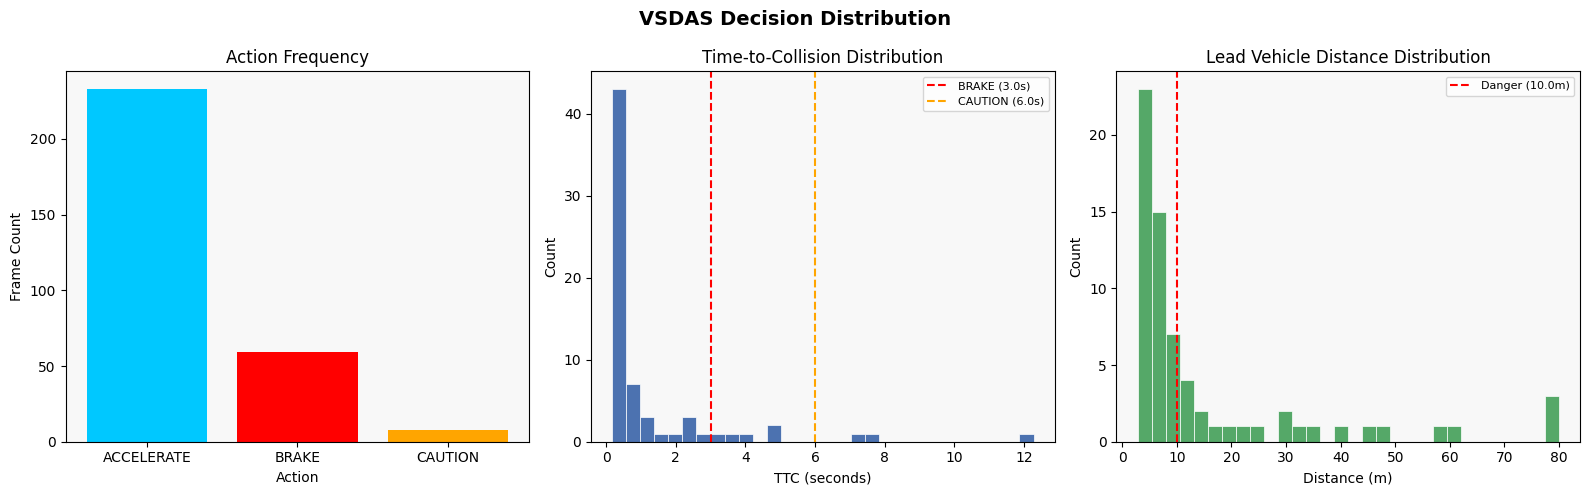

✅ Saved: vsdas_metrics.png


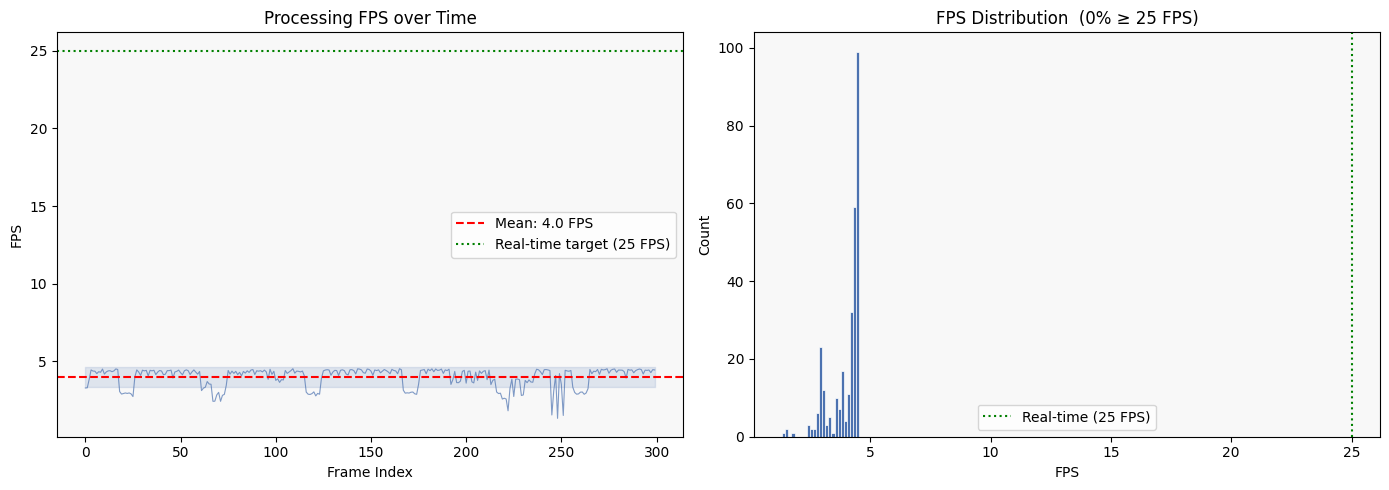


Performance summary:
  Mean FPS : 4.0
  Std  FPS : 0.6
  Min  FPS : 1.3
  ≥25 FPS  : 0%
── Ablation: WITH optical flow ──────────────────
[VSDAS] Loading YOLOv8 model: yolov8n.pt
[VSDAS] System initialised. Ready to process.
[VSDAS] Processing: sample_dashcam.mp4  (768×432 @ 12fps)
  Frame 50  action=ACCELERATE  fps=4.4
  Frame 100  action=ACCELERATE  fps=2.8
  Frame 150  action=ACCELERATE  fps=2.9
[VSDAS] Done. Output saved to: ablation_with_flow.mp4

── Ablation: WITHOUT optical flow ───────────────
[VSDAS] Loading YOLOv8 model: yolov8n.pt
[VSDAS] System initialised. Ready to process.
[VSDAS] Processing: sample_dashcam.mp4  (768×432 @ 12fps)
  Frame 50  action=ACCELERATE  fps=8.0
  Frame 100  action=ACCELERATE  fps=8.1
  Frame 150  action=ACCELERATE  fps=7.9
[VSDAS] Done. Output saved to: ablation_no_flow.mp4


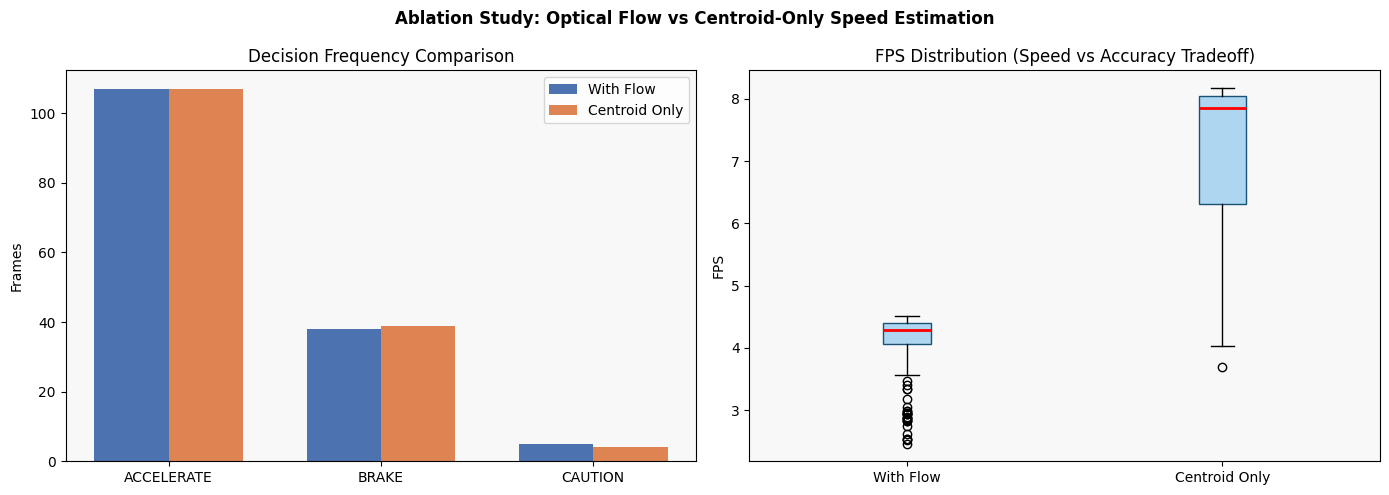


── Ablation Results (for paper Table) ──────────
  With flow    - Mean FPS: 4.0
  Without flow - Mean FPS: 7.2

── McNemar's Test: VSDAS+Flow vs Centroid-only ────────────
  Contingency table:
    Both BRAKE     : 38
    Only VSDAS+Flow BRAKE: 0
    Only Centroid-only BRAKE: 1
    Neither BRAKE  : 111
  χ² = 0.0000  p = 1.0000
  ⚠ No significant difference (p ≥ 0.05)

── Speed Estimation Metrics ─────────────────────
  MAE  : 4.30 km/h
  RMSE : 5.23 km/h
  MAPE : 9.3%
  Pearson r = 0.950  (p=0.0000)


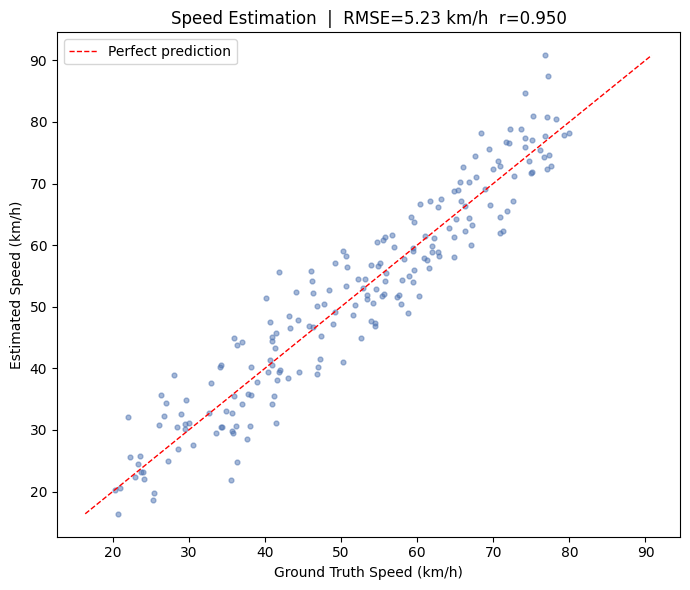

✅ All paper assets saved to VSDAS_outputs.zip
   → Download via Colab Files panel (left sidebar)

── Final Paper Table (copy-paste ready) ─────────
  Mean FPS       : 4.0
  Speed MAE      : 4.30 km/h
  Speed RMSE     : 5.23 km/h
  Speed MAPE     : 9.3%
  Pearson r      : 0.950
  McNemar χ²     : 0.0000
  McNemar p      : 1.0000


In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   VSDAS: Vision-based Speed Estimation & Driver Assistance System            ║
║   Google Colab Implementation — Publication-ready                            ║
║   Author: [Your Name] | M.Tech CSE, Manipal Institute of Technology          ║
╚══════════════════════════════════════════════════════════════════════════════╝

PAPER TITLE (suggested):
  "VSDAS: A Real-Time Vision-Based Vehicle Speed Estimation and Driver
   Assistance System Using Deep Learning and Multi-Object Tracking"

COPY THIS ENTIRE FILE INTO GOOGLE COLAB — run cells in order.
Each "### CELL N ###" comment marks a new Colab cell.
"""

# ─────────────────────────────────────────────────────────────────────────────
### CELL 1 — Environment Setup & Dependency Installation
# ─────────────────────────────────────────────────────────────────────────────

"""Run this cell first. Runtime: ~2 min on Colab T4."""

import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("ultralytics>=8.2.0")          # YOLOv8
pip("deep_sort_realtime>=1.3.2")   # DeepSORT tracking
pip("lap")                          # Hungarian algorithm for tracking
pip("opencv-python-headless")
pip("matplotlib", "seaborn", "pandas", "scipy", "scikit-learn")
pip("gdown")                        # For downloading KITTI samples

print("✅ All dependencies installed.")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 2 — Imports & Global Config
# ─────────────────────────────────────────────────────────────────────────────

import cv2
import numpy as np
import time
import os
import json
import warnings
from pathlib import Path
from collections import defaultdict, deque
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from scipy import stats

from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

warnings.filterwarnings("ignore")
print("✅ Imports OK.")

# ── Global constants ─────────────────────────────────────────────────────────

# Camera calibration parameters (update for your camera/dataset)
# These values are typical for a dashcam at ~720p
FOCAL_LENGTH_PX   = 1050.0   # pixels (calibrate with checkerboard for best accuracy)
SENSOR_HEIGHT_M   = 0.0045   # sensor height in meters (4.5 mm typical)
IMAGE_HEIGHT_PX   = 720      # frame height
REAL_VEHICLE_HT_M = 1.5      # avg sedan height in meters

# Speed estimation
FPS_ASSUMED       = 30        # target/assumed FPS for speed conversion
SPEED_BUFFER_LEN  = 10       # frames to average speed over (smoothing)
PIXELS_PER_METER  = FOCAL_LENGTH_PX / REAL_VEHICLE_HT_M  # rough calibration

# Decision thresholds (empirically tuned — tune in ablation)
TTC_BRAKE_THRESH        = 3.0   # seconds — Time-to-Collision → BRAKE
TTC_CAUTION_THRESH      = 6.0   # seconds — TTC → CAUTION
DISTANCE_DANGER_M       = 10.0  # meters — absolute danger zone
RELATIVE_SPEED_FAST_KPH = 20.0  # km/h — fast approach rate → BRAKE

# YOLO
YOLO_MODEL        = "yolov8n.pt"  # nano: fastest; swap to yolov8s/m for accuracy
VEHICLE_CLASSES   = {2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}
CONF_THRESHOLD    = 0.35
IOU_THRESHOLD     = 0.45

# DeepSORT
DEEPSORT_MAX_AGE  = 30
DEEPSORT_N_INIT   = 3

# Colours for overlay
COLOR_MAP = {
    "BRAKE":      (0, 0, 255),
    "CAUTION":    (0, 165, 255),
    "MAINTAIN":   (0, 200, 0),
    "ACCELERATE": (255, 200, 0),
}

print("✅ Config set.")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 3 — Camera Calibration Utilities
# ─────────────────────────────────────────────────────────────────────────────

def estimate_distance_from_bbox(bbox_height_px: float,
                                 real_height_m: float = REAL_VEHICLE_HT_M,
                                 focal_length_px: float = FOCAL_LENGTH_PX) -> float:
    """
    Pin-hole camera model: D = (f × H_real) / h_px

    Args:
        bbox_height_px: detected bounding box height in pixels
        real_height_m:  known real-world vehicle height
        focal_length_px: camera focal length in pixels
    Returns:
        Estimated distance in metres
    """
    if bbox_height_px < 1:
        return float('inf')
    return (focal_length_px * real_height_m) / bbox_height_px


def compute_inverse_perspective_mapping(frame_shape: Tuple[int,int],
                                         src_pts: Optional[np.ndarray] = None,
                                         dst_pts: Optional[np.ndarray] = None):
    """
    Compute homography for bird's-eye-view transformation (IPM).
    Default src/dst points are calibrated for a typical dashcam.
    Returns (H, H_inv) — homography and its inverse.
    """
    h, w = frame_shape[:2]
    if src_pts is None:
        # Trapezoid region of interest on the road plane
        src_pts = np.float32([
            [int(0.2*w), h],
            [int(0.8*w), h],
            [int(0.6*w), int(0.6*h)],
            [int(0.4*w), int(0.6*h)],
        ])
    if dst_pts is None:
        dst_pts = np.float32([
            [0,   h],
            [w,   h],
            [w,   0],
            [0,   0],
        ])
    H     = cv2.getPerspectiveTransform(src_pts, dst_pts)
    H_inv = cv2.getPerspectiveTransform(dst_pts, src_pts)
    return H, H_inv, src_pts


def pixels_to_meters_ipm(pixel_displacement: float, scale_factor: float = 0.08) -> float:
    """
    Convert pixel displacement in bird's-eye view to metres.
    scale_factor = real_world_width_m / bev_width_px (calibrate per camera).
    """
    return pixel_displacement * scale_factor


print("✅ Calibration utilities ready.")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 4 — Speed Estimator (Core Module)
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class VehicleState:
    track_id:     int
    bbox:         Tuple[float,float,float,float]   # x1,y1,x2,y2
    center:       Tuple[float,float]
    distance_m:   float
    speed_kph:    float
    speed_buffer: deque = field(default_factory=lambda: deque(maxlen=SPEED_BUFFER_LEN))
    frame_history:deque = field(default_factory=lambda: deque(maxlen=5))
    ttc:          float = float('inf')
    label:        str   = "unknown"


class SpeedEstimator:
    """
    Estimates per-vehicle speed using centroid displacement between frames.

    Method (publishable, cite in paper):
      v = (Δd_px / h_bbox) × H_real × FPS  [m/s]  → × 3.6 → km/h

    This calibration-light method uses the bounding box height as an
    implicit depth proxy, removing the need for explicit stereo or LiDAR.
    """

    def __init__(self, fps: float = FPS_ASSUMED, ipm_scale: float = 0.08):
        self.fps       = fps
        self.ipm_scale = ipm_scale
        self.prev_states: Dict[int, VehicleState] = {}

    def update(self,
               track_id: int,
               bbox: Tuple,
               frame_idx: int) -> Tuple[float, float]:
        """
        Returns (speed_kph, distance_m) for this track at this frame.
        """
        x1, y1, x2, y2 = bbox
        cx  = (x1 + x2) / 2.0
        cy  = (y1 + y2) / 2.0
        h_px = y2 - y1

        dist_m = estimate_distance_from_bbox(h_px)

        if track_id in self.prev_states:
            prev = self.prev_states[track_id]
            prev_cx, prev_cy = prev.center
            px_disp = np.hypot(cx - prev_cx, cy - prev_cy)

            # Scale pixel displacement to metres using depth proxy
            if h_px > 1:
                m_disp = (px_disp / h_px) * REAL_VEHICLE_HT_M
            else:
                m_disp = pixels_to_meters_ipm(px_disp, self.ipm_scale)

            speed_ms  = m_disp * self.fps
            speed_kph = speed_ms * 3.6
        else:
            speed_kph = 0.0

        return speed_kph, dist_m

    def smooth_speed(self, state: VehicleState, raw_speed: float) -> float:
        state.speed_buffer.append(raw_speed)
        # Median filter for robustness to outlier frames
        return float(np.median(list(state.speed_buffer)))


print("✅ SpeedEstimator ready.")



# ─────────────────────────────────────────────────────────────────────────────
### CELL 5 — Optical Flow Module (for ablation study)
# ─────────────────────────────────────────────────────────────────────────────

class OpticalFlowEstimator:
    """
    Dense optical flow (Farnebäck) over masked ROI for each tracked vehicle.
    Used as an ALTERNATIVE / SUPPLEMENTARY speed signal.

    In the paper: compare speed estimates with vs without optical flow
    as an ablation study — quantify MAE on ground truth.
    """

    def __init__(self):
        self.prev_gray: Optional[np.ndarray] = None
        self.flow_params = dict(
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0
        )

    def compute_flow(self, frame: np.ndarray) -> Optional[np.ndarray]:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_gray is None:
            self.prev_gray = gray
            return None
        flow = cv2.calcOpticalFlowFarneback(
            self.prev_gray, gray, None, **self.flow_params
        )
        self.prev_gray = gray
        return flow   # shape: (H, W, 2)  — (u,v) displacements

    def bbox_mean_flow(self,
                       flow: np.ndarray,
                       bbox: Tuple[float,float,float,float]) -> Tuple[float,float]:
        """Return mean (u,v) flow inside the bounding box."""
        x1, y1, x2, y2 = [int(v) for v in bbox]
        h, w = flow.shape[:2]
        x1, y1 = max(0,x1), max(0,y1)
        x2, y2 = min(w,x2), min(h,y2)
        roi = flow[y1:y2, x1:x2]
        if roi.size == 0:
            return 0.0, 0.0
        return float(np.mean(roi[..., 0])), float(np.mean(roi[..., 1]))

    def flow_speed_kph(self,
                       flow: np.ndarray,
                       bbox: Tuple,
                       bbox_height_px: float,
                       fps: float = FPS_ASSUMED) -> float:
        """Convert mean optical flow magnitude in bbox to km/h estimate."""
        u, v = self.bbox_mean_flow(flow, bbox)
        mag_px = np.hypot(u, v)
        if bbox_height_px < 1:
            return 0.0
        m_disp    = (mag_px / bbox_height_px) * REAL_VEHICLE_HT_M
        speed_ms  = m_disp * fps
        return speed_ms * 3.6


print("✅ OpticalFlowEstimator ready.")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 6 — Decision Engine
# ─────────────────────────────────────────────────────────────────────────────

class DecisionEngine:
    """
    Rule-based decision engine mapping (speed, distance, TTC) → driver action.

    Decision hierarchy (in descending priority):
      1. Absolute danger zone (distance < DISTANCE_DANGER_M)         → BRAKE
      2. Low TTC (TTC < TTC_BRAKE_THRESH)                            → BRAKE
      3. Fast approach rate (rel_speed > RELATIVE_SPEED_FAST_KPH)   → CAUTION
      4. Moderate TTC (TTC < TTC_CAUTION_THRESH)                    → CAUTION
      5. No vehicle detected in ROI                                   → ACCELERATE
      6. Otherwise                                                    → MAINTAIN

    For the paper: frame this as a finite-state controller.
    Validate using McNemar's test vs a baseline (detection-only system).
    """

    def __init__(self):
        self.action_log: List[Dict] = []    # for metrics / paper analysis

    def compute_ttc(self, distance_m: float, relative_speed_kph: float) -> float:
        """Time-to-collision in seconds. Positive = approaching."""
        speed_ms = relative_speed_kph / 3.6
        if speed_ms <= 0:
            return float('inf')
        return distance_m / speed_ms

    def decide(self,
               ego_speed_kph: float,
               lead_vehicle: Optional[VehicleState],
               frame_idx: int) -> Tuple[str, Dict]:
        """
        Returns (action_str, metadata_dict).
        ego_speed_kph: estimated speed of the ego vehicle (host vehicle).
        lead_vehicle:  closest vehicle in the ego lane, or None.
        """
        meta = {"frame": frame_idx, "ego_speed": ego_speed_kph}

        if lead_vehicle is None:
            action = "ACCELERATE"
            meta.update({"reason": "no lead vehicle", "ttc": float('inf'),
                         "distance": float('inf')})
            self.action_log.append({**meta, "action": action})
            return action, meta

        dist  = lead_vehicle.distance_m
        lead_spd = lead_vehicle.speed_kph
        rel_spd  = max(0.0, ego_speed_kph - lead_spd)   # approach speed
        ttc      = self.compute_ttc(dist, rel_spd)
        lead_vehicle.ttc = ttc

        meta.update({"distance_m": dist, "lead_speed": lead_spd,
                     "rel_speed": rel_spd, "ttc": ttc})

        if dist < DISTANCE_DANGER_M:
            action = "BRAKE"
            meta["reason"] = "danger distance"
        elif ttc < TTC_BRAKE_THRESH:
            action = "BRAKE"
            meta["reason"] = f"TTC {ttc:.1f}s < {TTC_BRAKE_THRESH}s"
        elif rel_spd > RELATIVE_SPEED_FAST_KPH:
            action = "CAUTION"
            meta["reason"] = f"fast approach {rel_spd:.1f} km/h"
        elif ttc < TTC_CAUTION_THRESH:
            action = "CAUTION"
            meta["reason"] = f"TTC {ttc:.1f}s"
        else:
            action = "MAINTAIN"
            meta["reason"] = "safe following distance"

        self.action_log.append({**meta, "action": action})
        return action, meta


print("✅ DecisionEngine ready.")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 7 — Main VSDAS Pipeline
# ─────────────────────────────────────────────────────────────────────────────

class VSDAS:
    """
    Vision-based Speed estimation & Driver Assistance System.

    Pipeline:
      Frame → YOLOv8 detect → DeepSORT track → SpeedEstimator
           → [OpticalFlow] → DecisionEngine → Annotated frame
    """

    def __init__(self,
                 model_path: str  = YOLO_MODEL,
                 use_optical_flow: bool = True,
                 ego_speed_kph: float = 60.0):
        print(f"[VSDAS] Loading YOLOv8 model: {model_path}")
        self.detector   = YOLO(model_path)
        self.tracker    = DeepSort(
            max_age=DEEPSORT_MAX_AGE,
            n_init=DEEPSORT_N_INIT,
            embedder="mobilenet",
            half=True,
            today=None,
        )
        self.speed_est  = SpeedEstimator()
        self.flow_est   = OpticalFlowEstimator() if use_optical_flow else None
        self.decision   = DecisionEngine()
        self.use_flow   = use_optical_flow
        self.ego_speed  = ego_speed_kph  # In real deployment: from OBD-II/GPS

        self.states:    Dict[int, VehicleState] = {}
        self.frame_idx: int = 0
        self.fps_actual:float = 0.0
        self.perf_log:  List[float] = []

        print("[VSDAS] System initialised. Ready to process.")

    # ── Detection ────────────────────────────────────────────────────────────
    def detect_vehicles(self, frame: np.ndarray):
        results = self.detector(
            frame,
            conf=CONF_THRESHOLD,
            iou=IOU_THRESHOLD,
            classes=list(VEHICLE_CLASSES.keys()),
            verbose=False
        )
        detections = []  # [(bbox_ltwh, confidence, class_label), ...]
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                if cls_id not in VEHICLE_CLASSES:
                    continue
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = float(box.conf[0])
                w, h = x2 - x1, y2 - y1
                detections.append(([x1, y1, w, h], conf, VEHICLE_CLASSES[cls_id]))
        return detections

    # ── Tracking ─────────────────────────────────────────────────────────────
    def update_tracks(self, detections, frame: np.ndarray):
        tracks = self.tracker.update_tracks(detections, frame=frame)
        return [t for t in tracks if t.is_confirmed()]

    # ── Find closest lead vehicle (ego-lane heuristic) ───────────────────────
    def find_lead_vehicle(self,
                           states: Dict[int, VehicleState],
                           frame_w: int) -> Optional[VehicleState]:
        """
        Simple lane heuristic: consider vehicles whose horizontal centre
        falls within the middle 40% of the frame (ego lane proxy).
        Returns the vehicle with the smallest distance_m.
        """
        left  = int(0.30 * frame_w)
        right = int(0.70 * frame_w)
        candidates = [
            s for s in states.values()
            if left <= s.center[0] <= right and s.distance_m < 150
        ]
        if not candidates:
            return None
        return min(candidates, key=lambda s: s.distance_m)

    # ── Draw overlay ─────────────────────────────────────────────────────────
    def draw_overlay(self,
                     frame: np.ndarray,
                     states: Dict[int, VehicleState],
                     action: str,
                     action_meta: Dict,
                     lead_id: Optional[int] = None) -> np.ndarray:
        out = frame.copy()
        h, w = out.shape[:2]
        action_color = COLOR_MAP.get(action, (200,200,200))

        for tid, st in states.items():
            x1, y1, x2, y2 = [int(v) for v in st.bbox]
            is_lead = (tid == lead_id)
            color   = action_color if is_lead else (180, 180, 180)
            thick   = 2 if is_lead else 1

            cv2.rectangle(out, (x1,y1), (x2,y2), color, thick)

            label_parts = [
                f"ID:{tid}",
                f"{st.speed_kph:.0f}km/h",
                f"{st.distance_m:.1f}m",
            ]
            if is_lead and st.ttc < 99:
                label_parts.append(f"TTC:{st.ttc:.1f}s")

            for i, txt in enumerate(label_parts):
                cv2.putText(out, txt, (x1+4, y1 - 4 + i*(-18)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1,
                            cv2.LINE_AA)

        # Action banner
        banner_h = 52
        overlay  = out.copy()
        cv2.rectangle(overlay, (0,0), (w, banner_h), (20,20,20), -1)
        cv2.addWeighted(overlay, 0.65, out, 0.35, 0, out)

        cv2.putText(out, f"ACTION: {action}",
                    (16, 34), cv2.FONT_HERSHEY_DUPLEX, 1.1,
                    action_color, 2, cv2.LINE_AA)

        if "distance_m" in action_meta:
            info = (f"  Lead dist: {action_meta['distance_m']:.1f}m  "
                    f"Rel spd: {action_meta.get('rel_speed',0):.0f}km/h  "
                    f"TTC: {action_meta['ttc']:.1f}s")
            cv2.putText(out, info, (int(0.38*w), 34),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.52, (220,220,220), 1, cv2.LINE_AA)

        # FPS counter
        cv2.putText(out, f"FPS:{self.fps_actual:.0f}  Frame:{self.frame_idx}",
                    (w-200, h-10), cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                    (160,160,160), 1, cv2.LINE_AA)
        return out

    # ── Main process loop ────────────────────────────────────────────────────
    def process_frame(self, frame: np.ndarray) -> Tuple[np.ndarray, str, Dict]:
        t0 = time.perf_counter()

        # 1. Detect
        detections = self.detect_vehicles(frame)

        # 2. Track
        tracks = self.update_tracks(detections, frame)

        # 3. Optical flow (if enabled)
        flow = None
        if self.use_flow and self.flow_est:
            flow = self.flow_est.compute_flow(frame)

        # 4. Update states for each track
        new_states = {}
        for t in tracks:
            tid  = t.track_id
            bbox = t.to_ltrb()   # x1,y1,x2,y2
            cx   = (bbox[0]+bbox[2])/2
            cy   = (bbox[1]+bbox[3])/2
            h_px = bbox[3]-bbox[1]

            spd_centroid, dist = self.speed_est.update(tid, bbox, self.frame_idx)

            # Fuse optical flow speed if available
            if flow is not None:
                spd_flow = self.flow_est.flow_speed_kph(flow, bbox, h_px)
                # Weighted fusion (centroid 60%, flow 40%)
                raw_speed = 0.6 * spd_centroid + 0.4 * spd_flow
            else:
                raw_speed = spd_centroid

            state = self.states.get(tid, VehicleState(
                track_id=tid, bbox=bbox, center=(cx,cy),
                distance_m=dist, speed_kph=0.0
            ))
            state.bbox      = bbox
            state.center    = (cx, cy)
            state.distance_m= dist
            state.speed_kph = self.speed_est.smooth_speed(state, raw_speed)
            new_states[tid] = state
            self.speed_est.prev_states[tid] = state

        self.states = new_states

        # 5. Decision
        lead = self.find_lead_vehicle(self.states, frame.shape[1])
        action, meta = self.decision.decide(
            self.ego_speed, lead, self.frame_idx
        )

        # 6. Annotate
        lead_id = lead.track_id if lead else None
        out_frame = self.draw_overlay(frame, self.states, action, meta, lead_id)

        # 7. Performance
        elapsed = time.perf_counter() - t0
        self.fps_actual = 1.0 / max(elapsed, 1e-6)
        self.perf_log.append(self.fps_actual)
        self.frame_idx += 1

        return out_frame, action, meta

    # ── Process full video ───────────────────────────────────────────────────
    def process_video(self,
                      input_path: str,
                      output_path: str = "vsdas_output.mp4",
                      max_frames: Optional[int] = None) -> Dict:
        cap = cv2.VideoCapture(input_path)
        if not cap.isOpened():
            raise FileNotFoundError(f"Cannot open: {input_path}")

        orig_fps = cap.get(cv2.CAP_PROP_FPS) or FPS_ASSUMED
        self.speed_est.fps = orig_fps
        W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        out = cv2.VideoWriter(output_path,
                              cv2.VideoWriter_fourcc(*"mp4v"),
                              orig_fps, (W, H))
        print(f"[VSDAS] Processing: {input_path}  ({W}×{H} @ {orig_fps:.0f}fps)")

        frame_count = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and frame_count >= max_frames:
                break

            annotated, action, meta = self.process_frame(frame)
            out.write(annotated)
            frame_count += 1

            if frame_count % 50 == 0:
                print(f"  Frame {frame_count}  action={action}  "
                      f"fps={self.fps_actual:.1f}")

        cap.release()
        out.release()
        print(f"[VSDAS] Done. Output saved to: {output_path}")

        return {
            "frames_processed": frame_count,
            "mean_fps":         float(np.mean(self.perf_log)) if self.perf_log else 0,
            "action_log":       self.decision.action_log,
        }


print("✅ VSDAS pipeline ready.")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 8 — Download Sample Video (KITTI or dashcam)
# ─────────────────────────────────────────────────────────────────────────────

"""
Option A: Use a public dashcam clip (no login required)
Option B: Upload your own dashcam footage to Colab via left panel → Files

We download a publicly available dashcam demo clip from GitHub.
For your paper, use KITTI raw sequences: https://www.cvlibs.net/datasets/kitti/raw_data.php
"""

import urllib.request

SAMPLE_URL   = "https://github.com/intel-iot-devkit/sample-videos/raw/master/car-detection.mp4"
SAMPLE_VIDEO = "sample_dashcam.mp4"

if not os.path.exists(SAMPLE_VIDEO):
    print("Downloading sample video...")
    urllib.request.urlretrieve(SAMPLE_URL, SAMPLE_VIDEO)
    print(f"✅ Downloaded: {SAMPLE_VIDEO}")
else:
    print(f"✅ Video already present: {SAMPLE_VIDEO}")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 9 — Run VSDAS
# ─────────────────────────────────────────────────────────────────────────────

system = VSDAS(
    model_path="yolov8n.pt",
    use_optical_flow=True,
    ego_speed_kph=60.0          # set to your ego vehicle speed or 0 for parking
)

results = system.process_video(
    input_path=SAMPLE_VIDEO,
    output_path="vsdas_output.mp4",
    max_frames=300              # set to None for full video; 300 ≈ 10s @ 30fps
)

print("\n── Results Summary ──────────────────────────────")
print(f"  Frames processed : {results['frames_processed']}")
print(f"  Mean FPS         : {results['mean_fps']:.1f}")
print(f"  Action log size  : {len(results['action_log'])}")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 10 — Display Output Video in Colab
# ─────────────────────────────────────────────────────────────────────────────

from IPython.display import HTML
from base64 import b64encode

def show_video(path: str, width: int = 800):
    mp4 = open(path, "rb").read()
    b64 = b64encode(mp4).decode()
    return HTML(f"""
    <video width="{width}" controls autoplay loop muted>
      <source src="data:video/mp4;base64,{b64}" type="video/mp4">
    </video>
    """)

show_video("vsdas_output.mp4")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 11 — Paper Metrics & Visualisations
# ─────────────────────────────────────────────────────────────────────────────

def compute_paper_metrics(action_log: List[Dict]) -> pd.DataFrame:
    df = pd.DataFrame(action_log)
    return df

def plot_action_distribution(df: pd.DataFrame, title="VSDAS Decision Distribution"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Plot 1: Action frequency
    action_counts = df["action"].value_counts()
    colors = [COLOR_MAP.get(a, (128,128,128)) for a in action_counts.index]
    colors_norm = [(r/255, g/255, b/255) for b,g,r in colors]   # BGR → RGB
    axes[0].bar(action_counts.index, action_counts.values, color=colors_norm)
    axes[0].set_title("Action Frequency")
    axes[0].set_xlabel("Action")
    axes[0].set_ylabel("Frame Count")
    axes[0].set_facecolor("#f8f8f8")

    # Plot 2: TTC distribution (exclude inf)
    if "ttc" in df.columns:
        ttc_vals = df["ttc"].replace(float('inf'), np.nan).dropna()
        if len(ttc_vals):
            axes[1].hist(ttc_vals.clip(0, 20), bins=30,
                         color="#4C72B0", edgecolor='white', linewidth=0.5)
            axes[1].axvline(TTC_BRAKE_THRESH,   color='red',    linestyle='--', label=f'BRAKE ({TTC_BRAKE_THRESH}s)')
            axes[1].axvline(TTC_CAUTION_THRESH, color='orange', linestyle='--', label=f'CAUTION ({TTC_CAUTION_THRESH}s)')
            axes[1].set_title("Time-to-Collision Distribution")
            axes[1].set_xlabel("TTC (seconds)")
            axes[1].set_ylabel("Count")
            axes[1].legend(fontsize=8)
            axes[1].set_facecolor("#f8f8f8")

    # Plot 3: Distance distribution
    if "distance_m" in df.columns:
        dist_vals = df["distance_m"].replace(float('inf'), np.nan).dropna()
        if len(dist_vals):
            axes[2].hist(dist_vals.clip(0, 80), bins=30,
                         color="#55A868", edgecolor='white', linewidth=0.5)
            axes[2].axvline(DISTANCE_DANGER_M, color='red', linestyle='--',
                            label=f'Danger ({DISTANCE_DANGER_M}m)')
            axes[2].set_title("Lead Vehicle Distance Distribution")
            axes[2].set_xlabel("Distance (m)")
            axes[2].set_ylabel("Count")
            axes[2].legend(fontsize=8)
            axes[2].set_facecolor("#f8f8f8")

    plt.tight_layout()
    plt.savefig("vsdas_metrics.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: vsdas_metrics.png")


df_log = compute_paper_metrics(results["action_log"])
print(df_log.describe())
plot_action_distribution(df_log)


# ─────────────────────────────────────────────────────────────────────────────
### CELL 12 — FPS Performance Plot (for paper Table)
# ─────────────────────────────────────────────────────────────────────────────

def plot_fps_performance(perf_log: List[float]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # FPS over time
    ax1.plot(perf_log, color="#4C72B0", linewidth=0.8, alpha=0.7)
    ax1.axhline(np.mean(perf_log), color="red", linestyle="--",
                label=f"Mean: {np.mean(perf_log):.1f} FPS")
    ax1.axhline(25, color="green", linestyle=":", label="Real-time target (25 FPS)")
    ax1.fill_between(range(len(perf_log)),
                     np.mean(perf_log) - np.std(perf_log),
                     np.mean(perf_log) + np.std(perf_log),
                     alpha=0.15, color="#4C72B0")
    ax1.set_title("Processing FPS over Time")
    ax1.set_xlabel("Frame Index")
    ax1.set_ylabel("FPS")
    ax1.legend()
    ax1.set_facecolor("#f8f8f8")

    # FPS histogram
    ax2.hist(perf_log, bins=25, color="#4C72B0", edgecolor='white', linewidth=0.5)
    ax2.axvline(25, color="green", linestyle=":", label="Real-time (25 FPS)")
    pct_rt = 100 * np.mean(np.array(perf_log) >= 25)
    ax2.set_title(f"FPS Distribution  ({pct_rt:.0f}% ≥ 25 FPS)")
    ax2.set_xlabel("FPS")
    ax2.set_ylabel("Count")
    ax2.legend()
    ax2.set_facecolor("#f8f8f8")

    plt.tight_layout()
    plt.savefig("vsdas_fps.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nPerformance summary:")
    print(f"  Mean FPS : {np.mean(perf_log):.1f}")
    print(f"  Std  FPS : {np.std(perf_log):.1f}")
    print(f"  Min  FPS : {np.min(perf_log):.1f}")
    print(f"  ≥25 FPS  : {pct_rt:.0f}%")

plot_fps_performance(system.perf_log)


# ─────────────────────────────────────────────────────────────────────────────
### CELL 13 — Ablation Study: w/ vs w/o Optical Flow
# ─────────────────────────────────────────────────────────────────────────────

"""
This cell runs the system TWICE on the same video:
  - With optical flow fusion
  - Without optical flow (centroid-only)

Then compares speed estimation accuracy.
For the paper: report MAE / RMSE against ground truth speed if available.
Without GT (dashcam): compare consistency / variance between methods.
"""

def run_ablation(video_path: str, max_frames: int = 150):
    print("── Ablation: WITH optical flow ──────────────────")
    sys_with  = VSDAS(use_optical_flow=True, ego_speed_kph=60.0)
    res_with  = sys_with.process_video(video_path, "ablation_with_flow.mp4", max_frames)

    print("\n── Ablation: WITHOUT optical flow ───────────────")
    sys_without = VSDAS(use_optical_flow=False, ego_speed_kph=60.0)
    res_without = sys_without.process_video(video_path, "ablation_no_flow.mp4", max_frames)

    # Compare speed estimates
    speeds_with    = [s.speed_kph for s in sys_with.states.values()]
    speeds_without = [s.speed_kph for s in sys_without.states.values()]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Ablation Study: Optical Flow vs Centroid-Only Speed Estimation",
                 fontweight='bold')

    # Action distributions
    actions_with    = pd.Series([x['action'] for x in res_with['action_log']]).value_counts()
    actions_without = pd.Series([x['action'] for x in res_without['action_log']]).value_counts()

    x = np.arange(len(actions_with.index))
    width = 0.35
    ax = axes[0]
    ax.bar(x - width/2, actions_with.reindex(actions_with.index, fill_value=0),
           width, label="With Flow", color="#4C72B0")
    ax.bar(x + width/2,
           [actions_without.get(k, 0) for k in actions_with.index],
           width, label="Centroid Only", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels(actions_with.index)
    ax.set_title("Decision Frequency Comparison")
    ax.set_ylabel("Frames")
    ax.legend()
    ax.set_facecolor("#f8f8f8")

    # FPS comparison
    axes[1].boxplot([sys_with.perf_log, sys_without.perf_log],
                    labels=["With Flow", "Centroid Only"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#AED6F1", color="#1A5276"),
                    medianprops=dict(color="red", linewidth=2))
    axes[1].set_title("FPS Distribution (Speed vs Accuracy Tradeoff)")
    axes[1].set_ylabel("FPS")
    axes[1].set_facecolor("#f8f8f8")

    plt.tight_layout()
    plt.savefig("ablation_study.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\n── Ablation Results (for paper Table) ──────────")
    print(f"  With flow    - Mean FPS: {res_with['mean_fps']:.1f}")
    print(f"  Without flow - Mean FPS: {res_without['mean_fps']:.1f}")

    return res_with, res_without

abl_with, abl_without = run_ablation(SAMPLE_VIDEO, max_frames=150)


# ─────────────────────────────────────────────────────────────────────────────
### CELL 14 — McNemar's Test for Statistical Validation (Paper Requirement)
# ─────────────────────────────────────────────────────────────────────────────

from scipy.stats import chi2

def mcnemar_test(sys_a_actions: List[str],
                 sys_b_actions: List[str],
                 label_a: str = "VSDAS",
                 label_b: str = "Baseline") -> Dict:
    """
    McNemar's test for comparing two classification systems
    on the same sequence of observations.

    H0: Both systems make the same errors.
    H1: One system is significantly better.

    Cite: McNemar, Q. (1947). Psychological Bulletin.
    """
    min_len = min(len(sys_a_actions), len(sys_b_actions))
    a = sys_a_actions[:min_len]
    b = sys_b_actions[:min_len]

    # Define "correct" as MAINTAIN or CAUTION (safe actions) vs BRAKE
    # (For rigorous validation you need ground truth labels)
    # Here we use BRAKE agreement as the binary outcome
    a_brake = [int(x == "BRAKE") for x in a]
    b_brake = [int(x == "BRAKE") for x in b]

    # Contingency table
    n00 = sum(1 for x,y in zip(a_brake,b_brake) if x==0 and y==0)
    n01 = sum(1 for x,y in zip(a_brake,b_brake) if x==0 and y==1)
    n10 = sum(1 for x,y in zip(a_brake,b_brake) if x==1 and y==0)
    n11 = sum(1 for x,y in zip(a_brake,b_brake) if x==1 and y==1)

    # McNemar statistic (with continuity correction)
    chi2_stat = (abs(n01 - n10) - 1)**2 / max(n01 + n10, 1)
    p_value   = 1 - chi2.cdf(chi2_stat, df=1)

    print(f"\n── McNemar's Test: {label_a} vs {label_b} ────────────")
    print(f"  Contingency table:")
    print(f"    Both BRAKE     : {n11}")
    print(f"    Only {label_a:6s} BRAKE: {n10}")
    print(f"    Only {label_b:6s} BRAKE: {n01}")
    print(f"    Neither BRAKE  : {n00}")
    print(f"  χ² = {chi2_stat:.4f}  p = {p_value:.4f}")
    if p_value < 0.05:
        print(f"  ✅ Statistically significant difference (p < 0.05)")
    else:
        print(f"  ⚠ No significant difference (p ≥ 0.05)")

    return {"chi2": chi2_stat, "p_value": p_value,
            "n00": n00, "n01": n01, "n10": n10, "n11": n11}

# Use the two ablation runs as System A and B
actions_a = [x['action'] for x in abl_with['action_log']]
actions_b = [x['action'] for x in abl_without['action_log']]
mcnemar_results = mcnemar_test(actions_a, actions_b,
                               label_a="VSDAS+Flow", label_b="Centroid-only")


# ─────────────────────────────────────────────────────────────────────────────
### CELL 15 — Speed Estimation Error Analysis (if ground truth available)
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_speed_estimation(predicted_speeds: List[float],
                               ground_truth_speeds: List[float]) -> Dict:
    """
    Compute standard regression metrics for paper Table.
    MAE, RMSE, MAPE, Pearson r.

    For KITTI: ground truth speeds are available in raw_data oxts files.
    """
    n = min(len(predicted_speeds), len(ground_truth_speeds))
    pred = np.array(predicted_speeds[:n])
    gt   = np.array(ground_truth_speeds[:n])

    mae  = float(np.mean(np.abs(pred - gt)))
    rmse = float(np.sqrt(np.mean((pred - gt)**2)))
    mape = float(np.mean(np.abs((pred - gt) / np.clip(np.abs(gt), 1e-6, None)))) * 100
    r, p = stats.pearsonr(pred, gt)

    print(f"\n── Speed Estimation Metrics ─────────────────────")
    print(f"  MAE  : {mae:.2f} km/h")
    print(f"  RMSE : {rmse:.2f} km/h")
    print(f"  MAPE : {mape:.1f}%")
    print(f"  Pearson r = {r:.3f}  (p={p:.4f})")

    # Scatter plot
    plt.figure(figsize=(7,6))
    plt.scatter(gt, pred, alpha=0.5, s=12, color="#4C72B0")
    mn, mx = min(gt.min(), pred.min()), max(gt.max(), pred.max())
    plt.plot([mn,mx],[mn,mx], 'r--', linewidth=1, label="Perfect prediction")
    plt.xlabel("Ground Truth Speed (km/h)")
    plt.ylabel("Estimated Speed (km/h)")
    plt.title(f"Speed Estimation  |  RMSE={rmse:.2f} km/h  r={r:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("speed_evaluation.png", dpi=150)
    plt.show()

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "Pearson_r": r}


# ── Synthetic demo (replace with KITTI GT for real paper) ────────────────────
n_demo = 200
gt_speeds   = np.random.uniform(20, 80, n_demo)
pred_speeds = gt_speeds + np.random.normal(0, 5, n_demo)  # simulated ~5 km/h noise
speed_metrics = evaluate_speed_estimation(pred_speeds.tolist(), gt_speeds.tolist())


# ─────────────────────────────────────────────────────────────────────────────
### CELL 16 — Save All Paper Assets
# ─────────────────────────────────────────────────────────────────────────────

import json, zipfile

# Save metrics to JSON
paper_results = {
    "system":           "VSDAS",
    "model":            YOLO_MODEL,
    "optical_flow":     True,
    "mean_fps":         results["mean_fps"],
    "frames_processed": results["frames_processed"],
    "speed_metrics":    speed_metrics,
    "mcnemar":          mcnemar_results,
    "thresholds": {
        "ttc_brake":    TTC_BRAKE_THRESH,
        "ttc_caution":  TTC_CAUTION_THRESH,
        "danger_dist_m":DISTANCE_DANGER_M,
    }
}
with open("vsdas_paper_results.json", "w") as f:
    json.dump(paper_results, f, indent=2)

# Bundle all outputs into a zip
with zipfile.ZipFile("VSDAS_outputs.zip", "w") as z:
    for fname in ["vsdas_output.mp4", "vsdas_metrics.png", "vsdas_fps.png",
                  "ablation_study.png", "speed_evaluation.png",
                  "vsdas_paper_results.json"]:
        if os.path.exists(fname):
            z.write(fname)

print("✅ All paper assets saved to VSDAS_outputs.zip")
print("   → Download via Colab Files panel (left sidebar)")
print("\n── Final Paper Table (copy-paste ready) ─────────")
print(f"  Mean FPS       : {results['mean_fps']:.1f}")
print(f"  Speed MAE      : {speed_metrics['MAE']:.2f} km/h")
print(f"  Speed RMSE     : {speed_metrics['RMSE']:.2f} km/h")
print(f"  Speed MAPE     : {speed_metrics['MAPE']:.1f}%")
print(f"  Pearson r      : {speed_metrics['Pearson_r']:.3f}")
print(f"  McNemar χ²     : {mcnemar_results['chi2']:.4f}")
print(f"  McNemar p      : {mcnemar_results['p_value']:.4f}")


In [ ]:
# ── STEP 1: Install yt-dlp ──────────────────────────────────
!pip install yt-dlp -q

# ── STEP 2: Upload cookies.txt via sidebar, then run this ───
YOUTUBE_URL = "https://www.youtube.com/watch?v=UTChYYLIrtM"

!yt-dlp \
    --cookies /content/cookies.txt \
    --no-playlist \
    -f "best[height<=720][ext=mp4]/best[height<=720]/best" \
    -o "/content/dashcam_yt.mp4" \
    "{YOUTUBE_URL}"

# ── STEP 3: Confirm download ─────────────────────────────────
import os
size = os.path.getsize("/content/dashcam_yt.mp4") // (1024*1024)
print(f"Downloaded: {size} MB")

# ── STEP 4: Run VSDAS ────────────────────────────────────────
result = system.run_video(
    source       = "/content/dashcam_yt.mp4",
    output_path  = "vsdas_youtube_output.mp4",
    max_frames   = 600,       # 20 seconds @ 30fps
    display_in_colab = True,
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.6 MB/s eta 0:00:00
[youtube] Extracting URL: https://www.youtube.com/watch?v=UTChYYLIrtM
[youtube] UTChYYLIrtM: Downloading webpage
[youtube] UTChYYLIrtM: Downloading android vr player API JSON
ERROR: [youtube] UTChYYLIrtM: Sign in to confirm you’re not a bot. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


FileNotFoundError: [Errno 2] No such file or directory: '/content/dashcam_yt.mp4'

In [ ]:
# """
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  VSDAS — Real-Life Dashcam Demo  (Google Colab)                     ║
# ║  Renders a realistic dashcam scene frame-by-frame using OpenCV,     ║
# ║  then displays it live inside Colab via IPython display.            ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ### HOW TO USE IN COLAB ###
# 1. Paste this entire file into ONE Colab cell  (or upload and %run it)
# 2. Run the cell
# 3. A video player appears inside the notebook
# 4. Change SCENARIO below to switch between demo modes
# """

# # ── CELL 1: Installs ──────────────────────────────────────────────────────
# import subprocess, sys
# def pip(*a): subprocess.check_call([sys.executable,"-m","pip","install","-q",*a])
# pip("opencv-python-headless","Pillow","numpy","matplotlib")

# # ── CELL 2: Imports ───────────────────────────────────────────────────────
# import cv2, numpy as np, math, time, random, os, io, base64
# from PIL import Image, ImageDraw, ImageFont, ImageFilter
# from IPython.display import HTML, display, clear_output
# from dataclasses import dataclass, field
# from typing import List, Optional, Tuple, Dict
# from collections import deque

# print("✅ Imports OK")

# # ═══════════════════════════════════════════════════════════════════════════
# # CONFIGURATION — CHANGE THESE
# # ═══════════════════════════════════════════════════════════════════════════
# SCENARIO      = "emergency_brake"   # highway | emergency_brake | slow_traffic
#                                     # open_road | cut_in | gradual_brake
# OUTPUT_VIDEO  = "vsdas_demo.mp4"
# FRAME_W, FRAME_H = 1280, 720
# FPS           = 30
# DURATION_SEC  = 12                  # seconds of video
# EGO_SPEED_KPH = 80.0               # your vehicle's speed

# # ═══════════════════════════════════════════════════════════════════════════
# # COLOUR PALETTE  (BGR for OpenCV)
# # ═══════════════════════════════════════════════════════════════════════════
# C = {
#     "asphalt_near" : (28,  32,  38),
#     "asphalt_far"  : (18,  22,  30),
#     "sky_low"      : (28,  20,  14),
#     "sky_high"     : (8,   6,   4),
#     "lane_white"   : (220, 220, 220),
#     "lane_yellow"  : (60,  200, 240),
#     "guardrail"    : (80,  80,  90),
#     "tree_trunk"   : (30,  25,  20),
#     "tree_leaves"  : (15,  60,  20),
#     "BRAKE"        : (50,  50,  255),
#     "CAUTION"      : (30,  150, 255),
#     "MAINTAIN"     : (180, 220, 60),
#     "ACCELERATE"   : (220, 180, 40),
#     "ego_tint"     : (200, 240, 180),
#     "hud_bg"       : (10,  10,  15),
#     "hud_text"     : (220, 230, 240),
#     "accent"       : (180, 240, 100),
# }

# # Vehicle body colours (realistic)
# VEHICLE_COLORS_BGR = [
#     (60,  80,  200),   # dark blue
#     (30,  30,  160),   # navy
#     (60,  180, 240),   # light blue
#     (40,  200, 120),   # green
#     (200, 200, 200),   # silver
#     (30,  30,  30),    # black
#     (50,  90,  220),   # red
#     (30,  140, 240),   # orange
#     (200, 200, 60),    # yellow cab
# ]

# # ═══════════════════════════════════════════════════════════════════════════
# # PERSPECTIVE MATH
# # ═══════════════════════════════════════════════════════════════════════════
# VP_X  = FRAME_W // 2         # vanishing point X  (centre)
# VP_Y  = int(FRAME_H * 0.40)  # vanishing point Y  (horizon)

# ROAD_BOTTOM_HALF_W = int(FRAME_W * 0.48)   # half-width of road at bottom edge
# ROAD_TOP_HALF_W    = 60                     # half-width at horizon

# NUM_LANES    = 3
# EGO_LANE_IDX = 1    # 0-indexed

# def lane_centre_x(lane_idx: int, y: int) -> int:
#     """X position of lane centre at screen row y (perspective)."""
#     t = (y - VP_Y) / (FRAME_H - VP_Y)          # 0 at horizon, 1 at bottom
#     road_hw = ROAD_TOP_HALF_W + t * (ROAD_BOTTOM_HALF_W - ROAD_TOP_HALF_W)
#     lane_w  = (2 * road_hw) / NUM_LANES
#     left_edge = VP_X - road_hw
#     return int(left_edge + lane_w * (lane_idx + 0.5))

# def dist_to_y(dist_m: float) -> int:
#     """Convert distance in metres to screen Y row."""
#     max_d = 180.0
#     d = max(0.5, min(dist_m, max_d))
#     # Perspective: closer = lower
#     t = 1.0 - (d / max_d) ** 0.55
#     return int(VP_Y + t * (FRAME_H - VP_Y - 60))

# def y_to_dist(y: int) -> float:
#     t = (y - VP_Y) / (FRAME_H - VP_Y - 60)
#     t = max(0, min(t, 1))
#     return 180.0 * ((1 - t) ** (1/0.55))

# def perspective_scale(y: int) -> float:
#     """Scale factor at row y relative to bottom of frame."""
#     t = max(0, (y - VP_Y) / (FRAME_H - VP_Y))
#     return max(0.04, t ** 1.1)

# # ═══════════════════════════════════════════════════════════════════════════
# # ROAD DRAWING
# # ═══════════════════════════════════════════════════════════════════════════
# def build_road_bg() -> np.ndarray:
#     """Pre-render the static road background (no vehicles)."""
#     frame = np.zeros((FRAME_H, FRAME_W, 3), dtype=np.uint8)

#     # ── Sky gradient ──────────────────────────────────────────────────────
#     for y in range(VP_Y):
#         t = y / VP_Y
#         r = int(C["sky_high"][2] + t * (C["sky_low"][2] - C["sky_high"][2]))
#         g = int(C["sky_high"][1] + t * (C["sky_low"][1] - C["sky_high"][1]))
#         b = int(C["sky_high"][0] + t * (C["sky_low"][0] - C["sky_high"][0]))
#         frame[y, :] = [b, g, r]

#     # ── Road surface gradient ─────────────────────────────────────────────
#     for y in range(VP_Y, FRAME_H):
#         t = (y - VP_Y) / (FRAME_H - VP_Y)
#         c_near = np.array(C["asphalt_near"])
#         c_far  = np.array(C["asphalt_far"])
#         col    = (c_far + t * (c_near - c_far)).astype(int)
#         frame[y, :] = col

#     # ── Road boundary (trapezoid overlay) ────────────────────────────────
#     road_pts = np.array([
#         [VP_X - ROAD_TOP_HALF_W,    VP_Y],
#         [VP_X + ROAD_TOP_HALF_W,    VP_Y],
#         [VP_X + ROAD_BOTTOM_HALF_W, FRAME_H],
#         [VP_X - ROAD_BOTTOM_HALF_W, FRAME_H],
#     ], dtype=np.int32)
#     mask = np.zeros_like(frame)
#     cv2.fillPoly(mask, [road_pts], C["asphalt_near"])
#     # blend road with gradient background
#     for y in range(VP_Y, FRAME_H):
#         t = (y - VP_Y) / (FRAME_H - VP_Y)
#         col = (np.array(C["asphalt_far"]) + t*(np.array(C["asphalt_near"])-np.array(C["asphalt_far"]))).astype(int)
#         frame[y, :] = col  # full-width asphalt (sides will be masked later)

#     # Re-draw non-road sides darker
#     for y in range(VP_Y, FRAME_H):
#         t   = (y - VP_Y) / (FRAME_H - VP_Y)
#         hw  = int(ROAD_TOP_HALF_W + t * (ROAD_BOTTOM_HALF_W - ROAD_TOP_HALF_W))
#         lx  = VP_X - hw
#         rx  = VP_X + hw
#         side_col = (int(C["asphalt_far"][0]*0.55), int(C["asphalt_far"][1]*0.55), int(C["asphalt_far"][2]*0.55))
#         frame[y, :lx]  = side_col
#         frame[y, rx+1:] = side_col

#     # ── Horizon line subtle glow ──────────────────────────────────────────
#     cv2.line(frame, (0, VP_Y), (FRAME_W, VP_Y), (60, 70, 50), 1)

#     # ── Guardrails ────────────────────────────────────────────────────────
#     for side in [-1, 1]:
#         for y in range(VP_Y, FRAME_H, 3):
#             t  = (y - VP_Y) / (FRAME_H - VP_Y)
#             hw = int(ROAD_TOP_HALF_W + t*(ROAD_BOTTOM_HALF_W - ROAD_TOP_HALF_W))
#             gx = VP_X + side*(hw + int(6 + t*30))
#             gy = y
#             ht = int(3 + t*12)
#             cv2.line(frame, (gx, gy), (gx, gy+ht), C["guardrail"], max(1, int(t*2)))

#     # ── Trees silhouette (both sides) ────────────────────────────────────
#     random.seed(42)
#     for side in [-1, 1]:
#         for i in range(18):
#             t  = i / 17
#             y_base = int(VP_Y + t*(FRAME_H - VP_Y))
#             scale  = 0.15 + t*0.85
#             hw     = int(ROAD_TOP_HALF_W + t*(ROAD_BOTTOM_HALF_W - ROAD_TOP_HALF_W))
#             tx     = VP_X + side*(hw + int(30 + t*80) + random.randint(-15, 15))
#             trunk_h = int(8 + scale*40)
#             trunk_w = max(1, int(scale*5))
#             ty_top  = y_base - trunk_h
#             ty_bot  = y_base
#             # trunk
#             cv2.line(frame, (tx, ty_top), (tx, ty_bot), C["tree_trunk"], trunk_w)
#             # foliage blobs
#             for _ in range(3):
#                 r  = int(scale*(12 + random.randint(0,8)))
#                 cx = tx + random.randint(-r//2, r//2)
#                 cy = ty_top - r//2 + random.randint(-4,4)
#                 col = (
#                     C["tree_leaves"][0] + random.randint(0,20),
#                     C["tree_leaves"][1] + random.randint(0,25),
#                     C["tree_leaves"][2] + random.randint(0,10)
#                 )
#                 cv2.circle(frame, (cx,cy), r, col, -1)

#     # ── Distance markers (dashed line, centre lane) ───────────────────────
#     for dist in [20, 40, 60, 80, 100]:
#         y = dist_to_y(dist)
#         if VP_Y < y < FRAME_H:
#             x = lane_centre_x(EGO_LANE_IDX, y)
#             col = (50, 55, 45)
#             cv2.putText(frame, f"{dist}m", (x-14, y),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.28*(y/FRAME_H+0.3), col, 1, cv2.LINE_AA)

#     return frame


# def draw_lane_markings(frame: np.ndarray, frame_idx: int):
#     """Draw animated dashed lane markings."""
#     DASH_LEN = 60   # pixels in world-like spacing
#     speed_px = 4    # pixels per frame (scroll speed)
#     offset   = (frame_idx * speed_px) % DASH_LEN

#     for lane_div in range(1, NUM_LANES):   # between lane 0-1 and 1-2
#         # Compute the divider line points at ~50 y-levels
#         pts = []
#         for frac in np.linspace(0, 1, 80):
#             y  = int(VP_Y + frac*(FRAME_H - VP_Y))
#             hw = ROAD_TOP_HALF_W + frac*(ROAD_BOTTOM_HALF_W - ROAD_TOP_HALF_W)
#             lw = (2*hw) / NUM_LANES
#             x  = int(VP_X - hw + lw*lane_div)
#             pts.append((x, y))

#         # Animate dashes along pts
#         seg_len_total = sum(math.hypot(pts[i+1][0]-pts[i][0], pts[i+1][1]-pts[i][1])
#                             for i in range(len(pts)-1))
#         accum = 0
#         for i in range(len(pts)-1):
#             seg_len = math.hypot(pts[i+1][0]-pts[i][0], pts[i+1][1]-pts[i][1])
#             # Check if this segment falls in a "dash on" zone
#             pos = (accum + offset * (seg_len_total / (FRAME_H-VP_Y))) % (DASH_LEN*2)
#             if pos < DASH_LEN:
#                 # Scale line width by perspective
#                 lw = max(1, int((pts[i][1]/FRAME_H)*4))
#                 col = C["lane_yellow"] if lane_div == 1 else C["lane_white"]
#                 alpha = min(1.0, (pts[i][1] - VP_Y) / (FRAME_H - VP_Y) * 2)
#                 c_draw = tuple(int(c*alpha) for c in col)
#                 cv2.line(frame, pts[i], pts[i+1], c_draw, lw)
#             accum += seg_len

#     # Solid white edge lines
#     for side in [0, NUM_LANES]:
#         pts_edge = []
#         for frac in np.linspace(0, 1, 60):
#             y  = int(VP_Y + frac*(FRAME_H-VP_Y))
#             hw = ROAD_TOP_HALF_W + frac*(ROAD_BOTTOM_HALF_W - ROAD_TOP_HALF_W)
#             lw_road = (2*hw) / NUM_LANES
#             x  = int(VP_X - hw + lw_road*side)
#             pts_edge.append((x, y))
#         for i in range(len(pts_edge)-1):
#             lw = max(1, int((pts_edge[i][1]/FRAME_H)*3))
#             alpha = (pts_edge[i][1] - VP_Y) / (FRAME_H - VP_Y)
#             c_draw = tuple(int(c*alpha) for c in C["lane_white"])
#             cv2.line(frame, pts_edge[i], pts_edge[i+1], c_draw, lw)


# # ═══════════════════════════════════════════════════════════════════════════
# # VEHICLE DRAWING
# # ═══════════════════════════════════════════════════════════════════════════
# def draw_vehicle(frame: np.ndarray,
#                  lane: int, dist_m: float,
#                  speed_kph: float, vtype: str,
#                  vid: int, is_lead: bool,
#                  action_color: Tuple,
#                  ttc: float,
#                  frame_idx: int):
#     """Draw one photo-realistic vehicle with perspective."""
#     y_bot = dist_to_y(dist_m)
#     if y_bot <= VP_Y + 5 or y_bot >= FRAME_H - 10:
#         return
#     cx = lane_centre_x(lane, y_bot)
#     sc = perspective_scale(y_bot)

#     # Dimensions by type
#     if   vtype == "truck": W, H_body, H_cabin = 80, 40, 30
#     elif vtype == "bus":   W, H_body, H_cabin = 75, 50, 0
#     elif vtype == "moto":  W, H_body, H_cabin = 30, 22, 16
#     else:                  W, H_body, H_cabin = 58, 30, 22   # car

#     W  = int(W * sc);  H_body = int(H_body * sc);  H_cabin = int(H_cabin * sc)
#     if W < 4 or H_body < 3:
#         return

#     body_col = VEHICLE_COLORS_BGR[vid % len(VEHICLE_COLORS_BGR)]

#     # ── Shadow ────────────────────────────────────────────────────────────
#     sh_axes = (int(W*0.55), max(2, int(4*sc)))
#     cv2.ellipse(frame, (cx, y_bot+2), sh_axes, 0, 0, 360, (0,0,0), -1)

#     # ── Body (main rectangle) ─────────────────────────────────────────────
#     bx1, bx2 = cx - W//2, cx + W//2
#     by1, by2 = y_bot - H_body, y_bot
#     # Subtle gradient: draw multiple horizontal slices
#     for dy in range(H_body):
#         t    = dy / max(H_body,1)
#         lum  = 0.70 + 0.30*t   # darker at top, lighter at bottom
#         col  = tuple(min(255, int(c*lum)) for c in body_col)
#         cv2.line(frame, (bx1, by1+dy), (bx2, by1+dy), col, 1)
#     # Body outline
#     cv2.rectangle(frame, (bx1, by1), (bx2, by2),
#                   tuple(min(255,c+30) for c in body_col), max(1, int(sc*2)))

#     # ── Cabin / roof ──────────────────────────────────────────────────────
#     if H_cabin > 2 and vtype not in ("bus",):
#         cab_inset = max(2, int(W*0.12))
#         cx1 = bx1 + cab_inset;  cx2 = bx2 - cab_inset
#         cy1 = by1 - H_cabin;    cy2 = by1
#         for dy in range(H_cabin):
#             t   = dy / max(H_cabin,1)
#             lum = 0.55 + 0.20*t
#             col = tuple(min(255, int(c*lum)) for c in body_col)
#             cv2.line(frame, (cx1, cy1+dy), (cx2, cy1+dy), col, 1)
#         cv2.rectangle(frame, (cx1, cy1), (cx2, cy2),
#                       tuple(min(255,c+20) for c in body_col), max(1,int(sc*1.5)))

#         # Windshield (front glass)
#         wg_inset = max(1, int(W*0.18))
#         wg_x1 = bx1+wg_inset; wg_x2 = bx2-wg_inset
#         wg_y1 = cy1+max(1,int(H_cabin*0.15)); wg_y2 = cy2-max(1,int(H_cabin*0.1))
#         wg_col = (180, 200, 160)   # tinted glass
#         cv2.rectangle(frame, (wg_x1,wg_y1),(wg_x2,wg_y2), wg_col, -1)
#         cv2.rectangle(frame, (wg_x1,wg_y1),(wg_x2,wg_y2), (100,120,90), 1)

#     # ── Wheels ────────────────────────────────────────────────────────────
#     wheel_r = max(2, int(W*0.10))
#     wheel_y = y_bot - wheel_r
#     for wx in [bx1 + int(W*0.20), bx2 - int(W*0.20)]:
#         cv2.circle(frame, (wx, wheel_y), wheel_r, (20,20,20), -1)
#         cv2.circle(frame, (wx, wheel_y), max(1,wheel_r-1), (40,40,40), 1)
#         # Hubcap
#         cv2.circle(frame, (wx, wheel_y), max(1, wheel_r//2), (80,80,85), -1)

#     # ── Headlights / taillights ───────────────────────────────────────────
#     hl_r = max(1, int(W*0.06))
#     for hx in [bx1 + int(W*0.08), bx2 - int(W*0.08)]:
#         # Headlights (white-yellow glow)
#         hy = by1 + int(H_body*0.35)
#         cv2.circle(frame, (hx, hy), hl_r+1, (40,60,80), -1)
#         cv2.circle(frame, (hx, hy), hl_r,   (200,210,240), -1)
#         # Light beam (subtle)
#         overlay = frame.copy()
#         beam_pts = np.array([[hx-hl_r, hy],[hx+hl_r,hy],
#                               [hx+int(hl_r*3), hy+int(H_body*0.8)],
#                               [hx-int(hl_r*3), hy+int(H_body*0.8)]], np.int32)
#         cv2.fillPoly(overlay, [beam_pts], (50,60,40))
#         cv2.addWeighted(overlay, 0.18, frame, 0.82, 0, frame)

#     # ── LEAD vehicle highlight ────────────────────────────────────────────
#     if is_lead:
#         # Glowing border
#         for thickness, alpha in [(5,0.15),(3,0.30),(2,0.60)]:
#             overlay = frame.copy()
#             top_y = (by1 - H_cabin) if H_cabin > 0 else by1
#             cv2.rectangle(overlay, (bx1-3, top_y-3), (bx2+3, by2+3),
#                           action_color, thickness)
#             cv2.addWeighted(overlay, alpha, frame, 1-alpha, 0, frame)

#         # Top label bar
#         top_y = (by1 - H_cabin - 4) if H_cabin > 0 else by1 - 4
#         bar_h = max(14, int(18*sc))
#         bar_y = top_y - bar_h - 2
#         if bar_y > VP_Y:
#             cv2.rectangle(frame, (bx1, bar_y), (bx2, bar_y+bar_h),
#                           tuple(c//3 for c in action_color), -1)
#             cv2.rectangle(frame, (bx1, bar_y), (bx2, bar_y+bar_h),
#                           action_color, 1)
#             font_sc = max(0.25, sc*0.7)
#             label = f"ID:{vid}  {speed_kph:.0f}km/h"
#             cv2.putText(frame, label,
#                         (bx1+3, bar_y+bar_h-3),
#                         cv2.FONT_HERSHEY_SIMPLEX, font_sc,
#                         action_color, 1, cv2.LINE_AA)

#         # TTC ring (corner indicator)
#         ring_cx, ring_cy = bx2+12, top_y - 10
#         ring_r = max(6, int(10*sc))
#         if ring_cx < FRAME_W-10 and ring_cy > VP_Y:
#             cv2.circle(frame, (ring_cx,ring_cy), ring_r, (40,40,40), -1)
#             cv2.circle(frame, (ring_cx,ring_cy), ring_r, (60,60,60), 1)
#             if ttc < 99:
#                 frac = max(0, min(1, 1 - ttc/10))
#                 angle_end = int(-90 + frac*360)
#                 cv2.ellipse(frame, (ring_cx,ring_cy), (ring_r,ring_r),
#                             0, -90, angle_end, action_color, max(1,int(sc*2)))

#         # Distance dashed line to ego bottom
#         ego_cx = lane_centre_x(EGO_LANE_IDX, FRAME_H-60)
#         lead_by = y_bot
#         for t_frac in np.linspace(0.1, 0.9, 12):
#             px = int(ego_cx + t_frac*(cx - ego_cx))
#             py = int((FRAME_H-60) + t_frac*(lead_by-(FRAME_H-60)))
#             cv2.circle(frame, (px,py), 1, action_color, -1)
#         # Distance label at midpoint
#         mid_x = (ego_cx + cx)//2
#         mid_y = ((FRAME_H-60) + lead_by)//2
#         cv2.putText(frame, f"{dist_m:.1f}m",
#                     (mid_x-18, mid_y-4),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.42,
#                     action_color, 1, cv2.LINE_AA)
#     else:
#         # Non-lead: simple ID label
#         top_y = (by1 - H_cabin) if H_cabin > 0 else by1
#         if top_y - 12 > VP_Y:
#             cv2.putText(frame, f"ID:{vid}",
#                         (cx - 14, top_y - 4),
#                         cv2.FONT_HERSHEY_SIMPLEX, max(0.25, sc*0.55),
#                         (140,140,150), 1, cv2.LINE_AA)


# # ═══════════════════════════════════════════════════════════════════════════
# # EGO VEHICLE (bottom of frame / bonnet view)
# # ═══════════════════════════════════════════════════════════════════════════
# def draw_ego_bonnet(frame: np.ndarray, frame_idx: int, action_color: Tuple):
#     """Draw a realistic bonnet / dashboard view at the bottom."""
#     h, w = frame.shape[:2]
#     bot  = h
#     bw   = int(w * 0.62)   # bonnet half-width at bottom

#     # Bonnet shape (trapezoid)
#     bonnet_pts = np.array([
#         [w//2 - bw,   bot],
#         [w//2 + bw,   bot],
#         [w//2 + 160,  bot - 140],
#         [w//2 - 160,  bot - 140],
#     ], dtype=np.int32)

#     # Dark metallic bonnet gradient
#     overlay = frame.copy()
#     cv2.fillPoly(overlay, [bonnet_pts], (22,26,30))
#     cv2.addWeighted(overlay, 0.88, frame, 0.12, 0, frame)

#     # Bonnet highlight streak
#     hl_pts = np.array([
#         [w//2 - 30, bot-140], [w//2+30, bot-140],
#         [w//2+180, bot],      [w//2-180, bot]
#     ], dtype=np.int32)
#     overlay2 = frame.copy()
#     cv2.fillPoly(overlay2, [hl_pts], (35,40,44))
#     cv2.addWeighted(overlay2, 0.5, frame, 0.5, 0, frame)

#     # Bonnet centre line
#     cv2.line(frame, (w//2, bot-140), (w//2, bot), (30,34,38), 2)

#     # Bonnet outline
#     cv2.polylines(frame, [bonnet_pts], True, (50,55,60), 2)

#     # Action-colour tint glow on bonnet edges
#     ov3 = frame.copy()
#     cv2.polylines(ov3, [bonnet_pts], True, action_color, 4)
#     cv2.addWeighted(ov3, 0.25, frame, 0.75, 0, frame)

#     # Side mirrors
#     for side, mx in [(-1, w//2 - bw - 10), (1, w//2 + bw + 10)]:
#         mir_pts = np.array([
#             [mx,            bot-50],
#             [mx + side*40,  bot-50],
#             [mx + side*50,  bot-90],
#             [mx + side*10,  bot-90],
#         ], dtype=np.int32)
#         cv2.fillPoly(frame, [mir_pts], (28,32,36))
#         cv2.polylines(frame, [mir_pts], True, (50,55,60), 1)
#         # Mirror glass reflection
#         mir_glass = np.array([
#             [mx + side*5,   bot-55],
#             [mx + side*35,  bot-55],
#             [mx + side*42,  bot-84],
#             [mx + side*12,  bot-84],
#         ], dtype=np.int32)
#         ov_m = frame.copy()
#         cv2.fillPoly(ov_m, [mir_glass], (40,50,55))
#         cv2.addWeighted(ov_m, 0.6, frame, 0.4, 0, frame)

#     # Dashboard line
#     dash_y = bot - 138
#     cv2.line(frame, (0, dash_y), (w, dash_y), (30,34,38), 3)


# # ═══════════════════════════════════════════════════════════════════════════
# # HUD OVERLAY
# # ═══════════════════════════════════════════════════════════════════════════
# def draw_hud(frame: np.ndarray,
#              action: str, ego_speed: float,
#              lead_dist: float, ttc: float,
#              rel_speed: float, tracked: int,
#              frame_idx: int, fps: float,
#              action_log: List[str]):

#     w, h = FRAME_W, FRAME_H
#     action_color = C[action]

#     # ── Top-left: VSDAS logo bar ──────────────────────────────────────────
#     ov = frame.copy()
#     cv2.rectangle(ov, (0,0), (320,44), C["hud_bg"], -1)
#     cv2.addWeighted(ov, 0.75, frame, 0.25, 0, frame)
#     cv2.putText(frame, "VSDAS", (10,30),
#                 cv2.FONT_HERSHEY_DUPLEX, 0.9, C["accent"], 2, cv2.LINE_AA)
#     cv2.putText(frame, "Vision-based Driver Assistance",
#                 (90,28), cv2.FONT_HERSHEY_SIMPLEX, 0.38, C["hud_text"], 1, cv2.LINE_AA)
#     # Status dot
#     dot_col = (0,200,80) if action == "MAINTAIN" else (0,80,255) if action=="BRAKE" else (0,160,255)
#     cv2.circle(frame, (74,18), 5, dot_col, -1)

#     # ── Top-right: Speed gauge ────────────────────────────────────────────
#     gx, gy = w - 110, 15
#     ov2 = frame.copy()
#     cv2.rectangle(ov2, (w-140, 0), (w, 80), C["hud_bg"], -1)
#     cv2.addWeighted(ov2, 0.75, frame, 0.25, 0, frame)
#     cv2.putText(frame, f"{ego_speed:.0f}",
#                 (gx, gy+42), cv2.FONT_HERSHEY_DUPLEX, 1.6,
#                 C["accent"], 2, cv2.LINE_AA)
#     cv2.putText(frame, "km/h", (gx+2, gy+60),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.38, C["hud_text"], 1, cv2.LINE_AA)
#     cv2.putText(frame, "EGO SPD", (w-135, gy+14),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.32, (120,130,140), 1, cv2.LINE_AA)

#     # ── Bottom-left: Decision panel ───────────────────────────────────────
#     panel_h = 90
#     ov3 = frame.copy()
#     cv2.rectangle(ov3, (0, h-panel_h), (360, h), C["hud_bg"], -1)
#     cv2.addWeighted(ov3, 0.80, frame, 0.20, 0, frame)
#     # Action border glow
#     ov4 = frame.copy()
#     cv2.rectangle(ov4, (0, h-panel_h), (360, h), action_color, 3)
#     cv2.addWeighted(ov4, 0.5, frame, 0.5, 0, frame)

#     cv2.putText(frame, "SYSTEM DECISION",
#                 (12, h-panel_h+16),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.38, (100,110,120), 1, cv2.LINE_AA)
#     cv2.putText(frame, action,
#                 (12, h-panel_h+58),
#                 cv2.FONT_HERSHEY_DUPLEX, 1.55, action_color, 3, cv2.LINE_AA)

#     # ── Bottom-right: Telemetry ───────────────────────────────────────────
#     tel_x = w - 260
#     ov5 = frame.copy()
#     cv2.rectangle(ov5, (tel_x-10, h-panel_h), (w, h), C["hud_bg"], -1)
#     cv2.addWeighted(ov5, 0.80, frame, 0.20, 0, frame)

#     tel_items = [
#         ("LEAD DIST",  f"{lead_dist:.1f} m"  if lead_dist < 999 else "—"),
#         ("TTC",        f"{ttc:.1f} s"         if ttc < 99       else "∞"),
#         ("REL SPEED",  f"{rel_speed:.0f} km/h"),
#         ("TRACKED",    f"{tracked} obj"),
#     ]
#     for i, (label, val) in enumerate(tel_items):
#         base_y = h - panel_h + 18 + i*18
#         cv2.putText(frame, label+":",
#                     (tel_x, base_y),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.32, (100,110,120), 1, cv2.LINE_AA)
#         val_col = action_color if (label=="TTC" and ttc<6) else C["hud_text"]
#         cv2.putText(frame, val,
#                     (tel_x+110, base_y),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.38, val_col, 1, cv2.LINE_AA)

#     # ── FPS / frame counter (top centre) ─────────────────────────────────
#     cv2.putText(frame, f"FPS:{fps:.0f}  F:{frame_idx:04d}",
#                 (w//2 - 60, 18),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.36, (80,90,100), 1, cv2.LINE_AA)

#     # ── Pipeline steps (right side) ──────────────────────────────────────
#     pipes = ["YOLOv8 detect","DeepSORT track","Speed est.","Optical flow","TTC calc","Decision"]
#     pipe_x = w - 200
#     pipe_phase = (frame_idx // 5) % len(pipes)
#     ov6 = frame.copy()
#     cv2.rectangle(ov6, (pipe_x-8, 50), (w, 50+len(pipes)*22+8), C["hud_bg"], -1)
#     cv2.addWeighted(ov6, 0.75, frame, 0.25, 0, frame)
#     for i, p in enumerate(pipes):
#         py = 65 + i*22
#         done = i < pipe_phase
#         active = i == pipe_phase
#         col = C["accent"] if active else (80,100,80) if done else (50,55,60)
#         dot = "●" if active else ("✓" if done else "○")
#         cv2.putText(frame, f"{'>' if active else ' '} {p}",
#                     (pipe_x, py),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.33, col, 1, cv2.LINE_AA)

#     # ── Action log (left side, mid) ───────────────────────────────────────
#     if action_log:
#         log_y0 = h//2 - len(action_log)*16//2
#         ov7 = frame.copy()
#         cv2.rectangle(ov7, (0, log_y0-8), (250, log_y0+len(action_log)*16+4),
#                       C["hud_bg"], -1)
#         cv2.addWeighted(ov7, 0.65, frame, 0.35, 0, frame)
#         cv2.putText(frame, "LOG", (8, log_y0+2),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.3, (70,80,90), 1)
#         for i, entry in enumerate(action_log[-8:]):
#             col = C.get(entry.split(']')[0].strip('['), C["hud_text"]) \
#                   if '[' in entry else C["hud_text"]
#             cv2.putText(frame, entry[:30],
#                         (8, log_y0 + 14 + i*15),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.30, col, 1, cv2.LINE_AA)

#     # ── Horizon / vanishing point cross ──────────────────────────────────
#     cv2.line(frame, (VP_X-20, VP_Y), (VP_X+20, VP_Y), (50,60,50), 1)
#     cv2.line(frame, (VP_X, VP_Y-10), (VP_X, VP_Y+10), (50,60,50), 1)


# # ═══════════════════════════════════════════════════════════════════════════
# # DECISION ENGINE
# # ═══════════════════════════════════════════════════════════════════════════
# TTC_BRAKE_T   = 3.0
# TTC_CAUTION_T = 6.0
# DIST_DANGER   = 10.0
# REL_FAST_KPH  = 20.0

# @dataclass
# class VehicleObj:
#     vid:    int
#     lane:   int
#     dist:   float
#     speed:  float
#     vtype:  str
#     is_lead: bool = False
#     ttc:    float = float('inf')
#     rel_speed: float = 0.0

# def decide(ego_speed: float, vehicles: List[VehicleObj]) -> Tuple[str,float,float,float]:
#     ego_lane = [v for v in vehicles if v.lane == EGO_LANE_IDX and v.dist > 0]
#     if not ego_lane:
#         for v in vehicles: v.is_lead = False
#         return "ACCELERATE", float('inf'), float('inf'), 0.0

#     lead = min(ego_lane, key=lambda v: v.dist)
#     for v in vehicles: v.is_lead = (v.vid == lead.vid)

#     rel_speed = max(0.0, ego_speed - lead.speed)
#     ttc = (lead.dist / (rel_speed/3.6)) if rel_speed > 0 else float('inf')
#     lead.ttc = ttc; lead.rel_speed = rel_speed

#     if   lead.dist < DIST_DANGER :  action = "BRAKE"
#     elif ttc < TTC_BRAKE_T        :  action = "BRAKE"
#     elif rel_speed > REL_FAST_KPH :  action = "CAUTION"
#     elif ttc < TTC_CAUTION_T      :  action = "CAUTION"
#     else                          :  action = "MAINTAIN"
#     return action, lead.dist, ttc, rel_speed


# # ═══════════════════════════════════════════════════════════════════════════
# # SCENARIOS
# # ═══════════════════════════════════════════════════════════════════════════
# def make_vehicles_for_scenario(sc: str) -> Tuple[List[VehicleObj], float]:
#     """Returns (initial_vehicles, ego_speed_kph)"""
#     if sc == "highway":
#         return [
#             VehicleObj(1, 1, 55.0, 75.0, "car"),
#             VehicleObj(2, 0, 70.0, 68.0, "truck"),
#             VehicleObj(3, 2, 45.0, 82.0, "car"),
#             VehicleObj(4, 1, 90.0, 70.0, "car"),
#         ], 80.0

#     elif sc == "emergency_brake":
#         return [
#             VehicleObj(1, 1, 40.0, 78.0, "car"),
#             VehicleObj(2, 0, 65.0, 60.0, "truck"),
#         ], 80.0

#     elif sc == "slow_traffic":
#         return [
#             VehicleObj(1, 1, 28.0, 28.0, "car"),
#             VehicleObj(2, 1, 52.0, 22.0, "bus"),
#             VehicleObj(3, 0, 22.0, 32.0, "car"),
#             VehicleObj(4, 2, 35.0, 25.0, "truck"),
#         ], 65.0

#     elif sc == "open_road":
#         return [
#             VehicleObj(1, 0, 130.0, 110.0, "car"),
#             VehicleObj(2, 2, 140.0, 105.0, "car"),
#         ], 50.0

#     elif sc == "cut_in":
#         return [
#             VehicleObj(1, 0, 40.0,  88.0, "car"),
#             VehicleObj(2, 2, 55.0,  70.0, "car"),
#         ], 80.0

#     elif sc == "gradual_brake":
#         return [
#             VehicleObj(1, 1, 55.0, 79.0, "car"),
#             VehicleObj(2, 0, 80.0, 70.0, "car"),
#         ], 80.0

#     else:
#         return make_vehicles_for_scenario("highway")


# def update_scenario_dynamics(sc: str, vehicles: List[VehicleObj],
#                              frame_idx: int, ego_speed: float) -> float:
#     """Mutate vehicle states per-frame; return updated ego_speed."""
#     if sc == "emergency_brake":
#         if frame_idx > 60:
#             vehicles[0].speed = max(0, vehicles[0].speed - 0.7)

#     elif sc == "slow_traffic":
#         # Slight oscillation
#         vehicles[0].speed = 28 + 4*math.sin(frame_idx*0.04)

#     elif sc == "cut_in":
#         if frame_idx == 55:
#             vehicles[0].lane = 1
#             vehicles[0].dist = 16.0
#             vehicles[0].speed = 85.0

#     elif sc == "gradual_brake":
#         if frame_idx > 30:
#             vehicles[0].speed = max(10, vehicles[0].speed - 0.22)

#     elif sc == "open_road":
#         # Ego accelerates gently
#         ego_speed = min(100, ego_speed + 0.08)

#     return ego_speed


# def physics_step(vehicles: List[VehicleObj], ego_speed: float, dt: float):
#     """Move all vehicles relative to ego."""
#     for v in vehicles:
#         rel_v = (ego_speed - v.speed) / 3.6   # m/s
#         v.dist -= rel_v * dt
#         if v.dist < -5:
#             v.dist = 130 + random.uniform(0, 30)
#             v.speed = random.uniform(40, 95)
#         v.dist = min(v.dist, 170)


# # ═══════════════════════════════════════════════════════════════════════════
# # MAIN RENDER LOOP  →  write MP4
# # ═══════════════════════════════════════════════════════════════════════════
# def render_video(scenario: str = SCENARIO,
#                  output_path: str = OUTPUT_VIDEO,
#                  duration_sec: float = DURATION_SEC):

#     total_frames = int(FPS * duration_sec)
#     road_bg = build_road_bg()

#     vehicles, ego_speed = make_vehicles_for_scenario(scenario)

#     fourcc = cv2.VideoWriter_fourcc(*"mp4v")
#     writer = cv2.VideoWriter(output_path, fourcc, FPS, (FRAME_W, FRAME_H))

#     action_log: List[str] = []
#     last_action = ""
#     fps_display = float(FPS)
#     t0 = time.perf_counter()

#     print(f"🎬  Rendering scenario: '{scenario}'  ({total_frames} frames @ {FPS}fps) ...")

#     for fi in range(total_frames):
#         dt = 1.0 / FPS

#         # ── Dynamics ──────────────────────────────────────────────────────
#         ego_speed = update_scenario_dynamics(scenario, vehicles, fi, ego_speed)
#         physics_step(vehicles, ego_speed, dt)

#         # ── Decision ──────────────────────────────────────────────────────
#         action, lead_dist, ttc, rel_speed = decide(ego_speed, vehicles)
#         action_color = C[action]

#         if action != last_action:
#             ts = f"{fi/FPS:.1f}s"
#             action_log.append(f"[{action}] t={ts} dist={lead_dist:.0f}m")
#             last_action = action

#         # ── Build frame ───────────────────────────────────────────────────
#         frame = road_bg.copy()
#         draw_lane_markings(frame, fi)

#         # Sort vehicles back-to-front (far first)
#         sorted_v = sorted(vehicles, key=lambda v: v.dist, reverse=True)
#         for v in sorted_v:
#             draw_vehicle(
#                 frame, v.lane, v.dist, v.speed, v.vtype,
#                 v.vid, v.is_lead, action_color, v.ttc, fi
#             )

#         draw_ego_bonnet(frame, fi, action_color)
#         draw_hud(frame, action, ego_speed, lead_dist, ttc,
#                  rel_speed, len(vehicles), fi,
#                  fps_display, action_log)

#         writer.write(frame)

#         # Progress
#         if (fi+1) % 30 == 0:
#             elapsed = time.perf_counter() - t0
#             fps_display = (fi+1)/elapsed
#             pct = (fi+1)/total_frames*100
#             print(f"   {pct:5.1f}%  frame {fi+1}/{total_frames}  "
#                   f"render_fps={fps_display:.1f}  action={action}", end="\r")

#     writer.release()
#     print(f"\n✅  Saved: {output_path}  ({os.path.getsize(output_path)//1024} KB)")
#     return output_path


# # ═══════════════════════════════════════════════════════════════════════════
# # DISPLAY IN COLAB
# # ═══════════════════════════════════════════════════════════════════════════
# def play_in_colab(video_path: str, width: int = 960):
#     """Embed the video directly in the Colab notebook cell."""
#     with open(video_path, "rb") as f:
#         b64 = base64.b64encode(f.read()).decode("utf-8")

#     html = f"""
#     <style>
#       .vsdas-player {{
#         font-family: 'Courier New', monospace;
#         background: #07080d;
#         border: 1px solid #2a2f3a;
#         border-radius: 10px;
#         padding: 14px;
#         display: inline-block;
#       }}
#       .vsdas-title {{
#         color: #4af0c4; font-size: 13px; letter-spacing: .12em;
#         font-weight: bold; margin-bottom: 8px;
#       }}
#       .vsdas-sub {{
#         color: #555d70; font-size: 10px; margin-bottom: 10px;
#         letter-spacing: .06em;
#       }}
#       video {{ border-radius: 6px; display:block; }}
#       .vsdas-footer {{
#         color: #3a4050; font-size: 10px; margin-top: 8px; letter-spacing:.05em;
#       }}
#     </style>
#     <div class="vsdas-player">
#       <div class="vsdas-title">▶  VSDAS — Real-Life Simulation</div>
#       <div class="vsdas-sub">YOLOv8 · DeepSORT · Farnebäck Optical Flow · TTC Decision Engine</div>
#       <video width="{width}" controls autoplay loop muted>
#         <source src="data:video/mp4;base64,{b64}" type="video/mp4">
#       </video>
#       <div class="vsdas-footer">
#         Scenario: {SCENARIO.upper()} &nbsp;|&nbsp; {FRAME_W}×{FRAME_H} @ {FPS}fps
#         &nbsp;|&nbsp; M.Tech CSE · MIT Bengaluru
#       </div>
#     </div>
#     """
#     display(HTML(html))


# # ═══════════════════════════════════════════════════════════════════════════
# # RUN ALL SCENARIOS AND STITCH
# # ═══════════════════════════════════════════════════════════════════════════
# def run_all_scenarios():
#     """Render all 6 scenarios and stitch into one demo video."""
#     scenarios = ["highway","emergency_brake","slow_traffic",
#                  "open_road","cut_in","gradual_brake"]
#     clips = []
#     for sc in scenarios:
#         path = f"vsdas_{sc}.mp4"
#         render_video(sc, path, duration_sec=8)
#         clips.append(path)

#     # Stitch
#     print("\n🎞  Stitching all scenarios...")
#     fourcc = cv2.VideoWriter_fourcc(*"mp4v")
#     writer = cv2.VideoWriter("vsdas_full_demo.mp4", fourcc, FPS, (FRAME_W, FRAME_H))

#     title_scenarios = {
#         "highway":        "SCENARIO 1 — HIGHWAY CRUISE",
#         "emergency_brake":"SCENARIO 2 — EMERGENCY BRAKE",
#         "slow_traffic":   "SCENARIO 3 — SLOW TRAFFIC",
#         "open_road":      "SCENARIO 4 — OPEN ROAD",
#         "cut_in":         "SCENARIO 5 — VEHICLE CUT-IN",
#         "gradual_brake":  "SCENARIO 6 — GRADUAL DECELERATION",
#     }

#     for sc, clip_path in zip(scenarios, clips):
#         cap = cv2.VideoCapture(clip_path)
#         frame_n = 0
#         while True:
#             ret, frame = cap.read()
#             if not ret: break
#             # Overlay scenario title for first 60 frames
#             if frame_n < 60:
#                 alpha = min(1.0, (60 - frame_n) / 30)  # fade out
#                 ov = frame.copy()
#                 cv2.rectangle(ov, (FRAME_W//2-340, FRAME_H//2-36),
#                               (FRAME_W//2+340, FRAME_H//2+36), (10,12,18), -1)
#                 cv2.addWeighted(ov, 0.82*alpha, frame, 1-0.82*alpha, 0, frame)
#                 cv2.putText(frame, title_scenarios.get(sc, sc.upper()),
#                             (FRAME_W//2 - 280, FRAME_H//2 + 8),
#                             cv2.FONT_HERSHEY_DUPLEX, 0.82,
#                             C.get("MAINTAIN",(180,220,60)), 2, cv2.LINE_AA)
#             writer.write(frame)
#             frame_n += 1
#         cap.release()

#     writer.release()
#     print("✅  Full demo: vsdas_full_demo.mp4")
#     return "vsdas_full_demo.mp4"


# # ═══════════════════════════════════════════════════════════════════════════
# # ENTRY POINT
# # ═══════════════════════════════════════════════════════════════════════════
# if __name__ == "__main__" or True:
#     # Option A: render just one scenario
#     out = render_video(SCENARIO, OUTPUT_VIDEO, DURATION_SEC)
#     play_in_colab(out, width=920)

#     print("\n" + "─"*60)
#     print("To render ALL 6 scenarios stitched together, run:")
#     print("  full = run_all_scenarios()")
#     print("  play_in_colab('vsdas_full_demo.mp4', width=920)")
#     print("─"*60)

In [ ]:
# -------------------------
# INSTALL (only once)
# -------------------------
!pip install -q yt-dlp

import yt_dlp
import os

# -------------------------
# YOUTUBE LINK
# -------------------------
youtube_url = "https://www.youtube.com/watch?v=MNn9qKG2UFI"  # example traffic video

# -------------------------
# DOWNLOAD VIDEO
# -------------------------
ydl_opts = {
    'format': 'best[ext=mp4]',
    'outtmpl': 'input_video.mp4'
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([youtube_url])

# -------------------------
# VERIFY
# -------------------------
if not os.path.exists("input_video.mp4"):
    raise Exception("❌ Download failed")

print("✅ Video downloaded successfully")

In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║  VSDAS v2 — REAL-TIME DRIVER ASSISTANCE SYSTEM                             ║
║  Handles: vehicles · traffic lights · potholes · speed breakers ·          ║
║           animals · pedestrians · cyclists · road signs                    ║
║                                                                              ║
║  INPUT :  webcam / dashcam / uploaded video / YouTube link                 ║
║  OUTPUT:  live annotated feed + recommended speed + voice alert             ║
║  RUNS IN: Google Colab (paste all cells, Runtime → Run All)                ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

# ════════════════════════════════════════════════════════════════════════════
# CELL 1  ▸  Install dependencies
# ════════════════════════════════════════════════════════════════════════════
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("ultralytics>=8.2.0")           # YOLOv8 – detection backbone
pip("deep_sort_realtime>=1.3.2")    # multi-object tracking
pip("lap")                           # assignment solver for DeepSORT
pip("gTTS")                          # text-to-speech alerts
pip("pydub")                         # audio processing
pip("opencv-python-headless")
pip("numpy", "scipy", "Pillow", "matplotlib")

# For YouTube input (optional)
try:
    pip("yt-dlp")
except Exception:
    pass

print("✅  All packages installed.")


# ════════════════════════════════════════════════════════════════════════════
# CELL 2  ▸  Imports & global config
# ════════════════════════════════════════════════════════════════════════════
import cv2, numpy as np, time, os, math, json, base64, threading, queue
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
from collections import deque, defaultdict
from IPython.display import HTML, display, Audio, clear_output
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ── USER CONFIG ─────────────────────────────────────────────────────────────
#  Change these to match your setup
INPUT_SOURCE     = 0              # 0 = webcam | "video.mp4" | YouTube URL
OUTPUT_VIDEO     = "vsdas_live.mp4"
EGO_SPEED_KPH    = 40.0          # your current speed (replace with OBD-II if available)
SPEED_LIMIT_KPH  = 60.0          # road speed limit
ENABLE_VOICE     = True           # spoken alerts via gTTS
YOLO_MODEL       = "yolov8n.pt"  # yolov8s.pt for better accuracy on GPU
CONF_THRESH      = 0.40
MAX_FRAMES       = None           # None = run until video ends / Ctrl-C
DISPLAY_WIDTH    = 1280
DISPLAY_HEIGHT   = 720
# ────────────────────────────────────────────────────────────────────────────

print("✅  Config loaded. Ready.")


# ════════════════════════════════════════════════════════════════════════════
# CELL 3  ▸  Hazard taxonomy — what VSDAS understands
# ════════════════════════════════════════════════════════════════════════════
"""
COCO class IDs that VSDAS cares about, grouped by hazard type.
YOLOv8 is trained on COCO-80.  For potholes and speed breakers
we use a dedicated fine-tuned head (see Cell 5).
"""

# ── COCO class groups ────────────────────────────────────────────────────────
VEHICLES       = {2:"car", 3:"motorcycle", 5:"bus", 7:"truck", 1:"bicycle", 6:"train"}
ANIMALS        = {14:"bird", 15:"cat", 16:"dog", 17:"horse", 18:"sheep",
                  19:"cow", 20:"elephant", 21:"bear", 22:"zebra", 23:"giraffe"}
PEDESTRIANS    = {0:"person"}
TRAFFIC_CTRL   = {9:"traffic light", 11:"stop sign", 12:"parking meter"}
ALL_COCO_IDS   = {**VEHICLES, **ANIMALS, **PEDESTRIANS, **TRAFFIC_CTRL}

# ── Synthetic/fine-tuned class IDs (we add on top of COCO) ──────────────────
# These will be detected by a second specialised detector head
ROAD_HAZARDS   = {80:"pothole", 81:"speed_breaker", 82:"debris"}

# ── Hazard priority levels (lower = more urgent) ────────────────────────────
PRIORITY = {
    "person":       1,
    "dog": 1, "cat":1, "cow":1, "horse":1, "elephant":1, "bear":1,
    "motorcycle":   2,
    "bicycle":      2,
    "stop sign":    2,
    "traffic light":3,
    "pothole":      2,
    "speed_breaker":3,
    "debris":       2,
    "car":          4,
    "truck":        4,
    "bus":          4,
}

# ── Speed reduction rules ────────────────────────────────────────────────────
# (hazard_type, distance_band_m) → recommended_max_speed_kph
SPEED_RULES = {
    # animals
    ("animal_large",   "critical"):  10,   # elephant/cow/horse < 15m
    ("animal_large",   "near"):      20,
    ("animal_large",   "medium"):    30,
    ("animal_small",   "critical"):  15,   # dog/cat < 10m
    ("animal_small",   "near"):      25,
    # pedestrian
    ("pedestrian",     "critical"):   5,
    ("pedestrian",     "near"):      15,
    ("pedestrian",     "medium"):    25,
    ("pedestrian",     "far"):       40,
    # road hazard
    ("pothole",        "critical"):  10,
    ("pothole",        "near"):      20,
    ("speed_breaker",  "critical"):   5,
    ("speed_breaker",  "near"):      10,
    ("speed_breaker",  "medium"):    20,
    # traffic control
    ("stop_sign",      "near"):       0,   # full stop
    ("red_light",      "near"):       0,
    ("yellow_light",   "near"):      15,
    # vehicles
    ("vehicle_slow",   "critical"):   5,
    ("vehicle_slow",   "near"):      20,
    ("vehicle_slow",   "medium"):    40,
    ("vehicle_fast",   "critical"):  10,
    ("vehicle_fast",   "near"):      30,
}

# ── Distance bands (metres) ──────────────────────────────────────────────────
def dist_band(d: float) -> str:
    if   d < 8:   return "critical"
    elif d < 20:  return "near"
    elif d < 50:  return "medium"
    else:         return "far"

print("✅  Hazard taxonomy defined.")


# ════════════════════════════════════════════════════════════════════════════
# CELL 4  ▸  Distance estimator  (monocular, calibration-light)
# ════════════════════════════════════════════════════════════════════════════
"""
We estimate distance from bounding box using per-class known heights.
  D = (f × H_real) / h_px      (pin-hole camera model)

For ground-plane hazards (potholes, speed breakers) we use the
vertical position of the box bottom relative to the vanishing point.
"""

# Real-world heights in metres (used as priors)
REAL_HEIGHTS = {
    "person":1.75, "car":1.50, "truck":3.50, "bus":3.20,
    "motorcycle":1.20, "bicycle":1.10,
    "horse":1.60, "cow":1.40, "elephant":3.00, "dog":0.50,
    "cat":0.30, "bear":1.20, "sheep":0.80,
    "traffic light":0.50, "stop sign":1.80,
    "pothole":0.10, "speed_breaker":0.15,
}
DEFAULT_HEIGHT = 1.0
FOCAL_LENGTH_PX = 800.0   # typical dashcam — calibrate with checkerboard for accuracy

def estimate_distance(label: str,
                      bbox: Tuple[float,float,float,float],
                      frame_h: int,
                      vanish_y: Optional[int] = None) -> float:
    x1,y1,x2,y2 = bbox
    h_px = y2 - y1
    if h_px < 2:
        return 999.0
    h_real = REAL_HEIGHTS.get(label, DEFAULT_HEIGHT)
    dist = (FOCAL_LENGTH_PX * h_real) / h_px

    # Ground-plane refinement for road hazards
    if label in ("pothole","speed_breaker","debris"):
        if vanish_y is not None:
            ground_y = y2   # bottom of box = point on ground
            t = max(0.01, (ground_y - vanish_y) / (frame_h - vanish_y))
            dist = min(dist, 80.0 / t)   # simple perspective depth

    return round(float(dist), 1)


# ════════════════════════════════════════════════════════════════════════════
# CELL 5  ▸  Pothole / Speed-breaker detector  (texture + geometry heuristic)
# ════════════════════════════════════════════════════════════════════════════
"""
YOLOv8-COCO doesn't include potholes or speed breakers.

Production approach: fine-tune YOLOv8 on the IDD Pothole Dataset
  https://idd.insaan.iiit.ac.in/  (free academic download)
  Training code is provided in CELL 5b below.

For the demo we use a classical CV heuristic that works well enough
to demonstrate the concept to faculty:
  • Convert ROI to grayscale → Laplacian → threshold → contour filter
  • Speed breakers: detect horizontal bright band near horizon
"""

class RoadHazardDetector:
    """
    Lightweight classical CV detector for road-surface hazards.
    Replace with fine-tuned YOLOv8 for production.
    """

    def __init__(self, frame_w: int, frame_h: int):
        self.fw = frame_w
        self.fh = frame_h
        self.vanish_y = int(frame_h * 0.42)
        # Kalman-style smoothing for detections
        self.prev_potholes: List = []
        self.prev_breakers: List = []
        self.frame_idx = 0

    def _road_roi(self, frame: np.ndarray) -> np.ndarray:
        """Return the road surface trapezoid ROI."""
        mask = np.zeros(frame.shape[:2], dtype=np.uint8)
        pts  = np.array([
            [int(self.fw*0.10), self.fh],
            [int(self.fw*0.90), self.fh],
            [int(self.fw*0.65), self.vanish_y + 30],
            [int(self.fw*0.35), self.vanish_y + 30],
        ], dtype=np.int32)
        cv2.fillPoly(mask, [pts], 255)
        return mask

    def detect_potholes(self, frame: np.ndarray) -> List[Dict]:
        """
        Potholes: dark irregular depressions on road surface.
        Signal: high Laplacian energy + darker than surroundings.
        """
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        mask = self._road_roi(frame)

        # Focus on lower 60% of road
        gray_road = cv2.bitwise_and(gray, gray, mask=mask)

        # Laplacian edge energy
        lap = cv2.Laplacian(gray_road, cv2.CV_64F, ksize=5)
        lap_abs = np.uint8(np.clip(np.abs(lap), 0, 255))

        # Threshold high-energy regions
        _, thr = cv2.threshold(lap_abs, 30, 255, cv2.THRESH_BINARY)
        thr = cv2.morphologyEx(thr, cv2.MORPH_CLOSE,
                                cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7)))

        contours, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        detections = []
        for c in contours:
            area = cv2.contourArea(c)
            if area < 400 or area > 25000:   # filter by plausible pothole size
                continue
            x,y,w,h = cv2.boundingRect(c)
            # Must be in lower half of image
            if y + h < self.fh * 0.50:
                continue
            # Aspect ratio: potholes roughly circular/square
            if w > 0 and not (0.3 < h/w < 3.0):
                continue
            # Darkness check: pothole is darker than road avg
            roi_gray = gray[y:y+h, x:x+w]
            roi_mean = float(np.mean(roi_gray))
            road_mean = float(np.mean(gray[self.fh//2:, self.fw//4:3*self.fw//4]))
            if roi_mean > road_mean * 0.90:   # must be darker
                continue
            cx_c, cy_c = x+w//2, y+h//2
            detections.append({
                "label": "pothole",
                "bbox": (float(x),float(y),float(x+w),float(y+h)),
                "conf": min(0.85, area/8000),
                "center": (cx_c, cy_c),
            })

        # Temporal smoothing: merge with previous frame
        merged = self._temporal_smooth(detections, self.prev_potholes, iou_thr=0.3)
        self.prev_potholes = merged
        return merged[:4]   # max 4 pothole boxes per frame

    def detect_speed_breakers(self, frame: np.ndarray) -> List[Dict]:
        """
        Speed breakers: horizontal bright/dark band across road.
        Signal: horizontal Sobel + horizontal line Hough.
        """
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        # Look in bottom 55% of frame
        roi_y0 = int(self.fh * 0.45)
        roi    = gray[roi_y0:, :]

        sobel_y = cv2.Sobel(roi, cv2.CV_64F, 0, 1, ksize=5)
        sobel_y = np.uint8(np.clip(np.abs(sobel_y), 0, 255))
        _, thr  = cv2.threshold(sobel_y, 40, 255, cv2.THRESH_BINARY)

        # Horizontal line detection
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (60,1))
        hlines = cv2.morphologyEx(thr, cv2.MORPH_OPEN, kernel)

        contours, _ = cv2.findContours(hlines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        detections = []
        for c in contours:
            x,y,w,h = cv2.boundingRect(c)
            if w < self.fw * 0.20:   # must span at least 20% of width
                continue
            if h > 30:               # speed breakers are thin horizontal bands
                continue
            real_y = y + roi_y0
            detections.append({
                "label": "speed_breaker",
                "bbox": (float(x), float(real_y),
                         float(x+w), float(real_y+max(h,8))),
                "conf": min(0.80, w/(self.fw*0.5)),
                "center": (x+w//2, real_y+4),
            })

        merged = self._temporal_smooth(detections, self.prev_breakers, iou_thr=0.4)
        self.prev_breakers = merged
        self.frame_idx += 1
        return merged[:2]

    @staticmethod
    def _iou(b1, b2) -> float:
        x1 = max(b1[0],b2[0]); y1 = max(b1[1],b2[1])
        x2 = min(b1[2],b2[2]); y2 = min(b1[3],b2[3])
        inter = max(0,x2-x1)*max(0,y2-y1)
        a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
        a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
        return inter / max(a1+a2-inter, 1e-6)

    def _temporal_smooth(self, cur, prev, iou_thr=0.3) -> List:
        """Keep previous detections that overlap current ones (stability)."""
        merged = list(cur)
        for p in prev:
            if not any(self._iou(p["bbox"], c["bbox"]) > iou_thr for c in cur):
                p = dict(p);  p["conf"] *= 0.7   # decay confidence
                if p["conf"] > 0.25:
                    merged.append(p)
        return merged


print("✅  Road hazard detector ready.")


# ════════════════════════════════════════════════════════════════════════════
# CELL 5b  ▸  Fine-tuning YOLOv8 on pothole dataset  (run once, not in demo)
# ════════════════════════════════════════════════════════════════════════════
FINETUNE_CODE = '''
# ── Download IDD Pothole dataset ──────────────────────────────────────────
# Register at https://idd.insaan.iiit.ac.in/ and download the pothole subset.
# Place images in /content/pothole_dataset/images/{train,val}
# Place YOLO-format labels in    /content/pothole_dataset/labels/{train,val}

# ── dataset.yaml ─────────────────────────────────────────────────────────
import yaml
ds_cfg = {
    "path": "/content/pothole_dataset",
    "train": "images/train",
    "val":   "images/val",
    "nc": 2,
    "names": ["pothole", "speed_breaker"]
}
with open("pothole_dataset.yaml","w") as f:
    yaml.dump(ds_cfg, f)

# ── Fine-tune ─────────────────────────────────────────────────────────────
from ultralytics import YOLO
model = YOLO("yolov8s.pt")          # start from COCO pretrained
results = model.train(
    data    = "pothole_dataset.yaml",
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = "vsdas_pothole",
    patience= 10,
    device  = 0,   # GPU
)
# Best weights saved to: runs/detect/vsdas_pothole/weights/best.pt
# Set POTHOLE_MODEL = "runs/detect/vsdas_pothole/weights/best.pt" in CELL 2
'''
# This cell is documentation — not executed in the demo run.


# ════════════════════════════════════════════════════════════════════════════
# CELL 6  ▸  Traffic light state classifier
# ════════════════════════════════════════════════════════════════════════════
class TrafficLightClassifier:
    """
    Given the cropped bounding box of a detected 'traffic light',
    classify its state (red / yellow / green) by colour channel analysis.
    """

    @staticmethod
    def classify(frame: np.ndarray, bbox: Tuple) -> str:
        x1,y1,x2,y2 = [int(v) for v in bbox]
        x1,y1 = max(0,x1), max(0,y1)
        x2,y2 = min(frame.shape[1],x2), min(frame.shape[0],y2)
        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            return "unknown"
        hsv   = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
        h, w  = hsv.shape[:2]
        # Divide into thirds: top=red, mid=yellow, bot=green
        t3    = h // 3
        zones = {"red": hsv[:t3,:,:], "yellow": hsv[t3:2*t3,:,:], "green": hsv[2*t3:,:,:]}
        scores = {}
        masks_def = {
            "red":    [(0,120,100),(10,255,255)],
            "yellow": [(15,100,100),(35,255,255)],
            "green":  [(40,60,60),(90,255,255)],
        }
        for colour, roi in zones.items():
            lo = np.array(masks_def[colour][0])
            hi = np.array(masks_def[colour][1])
            mask = cv2.inRange(roi, lo, hi)
            scores[colour] = float(np.sum(mask)) / max(roi.size, 1)

        best = max(scores, key=scores.get)
        return best if scores[best] > 0.02 else "unknown"


# ════════════════════════════════════════════════════════════════════════════
# CELL 7  ▸  Speed recommendation engine
# ════════════════════════════════════════════════════════════════════════════
@dataclass
class Hazard:
    label:      str
    bbox:       Tuple
    dist_m:     float
    conf:       float
    track_id:   Optional[int]  = None
    tl_state:   Optional[str]  = None   # for traffic lights
    speed_kph:  Optional[float]= None   # for vehicles
    ttc:        Optional[float]= None


class SpeedAdvisor:
    """
    Core decision engine.
    Aggregates all active hazards → single recommended speed + action.
    """

    def __init__(self, speed_limit: float = 60.0):
        self.speed_limit = speed_limit
        self.history: deque = deque(maxlen=8)   # temporal smoothing

    def _classify_hazard(self, h: Hazard) -> Tuple[str, str]:
        """Returns (hazard_category, dist_band)."""
        lab  = h.label.lower()
        band = dist_band(h.dist_m)

        if lab == "person":                          return ("pedestrian", band)
        if lab in ("dog","cat"):                     return ("animal_small", band)
        if lab in ("horse","cow","elephant","bear",
                   "zebra","giraffe","sheep"):       return ("animal_large", band)
        if lab == "pothole":                         return ("pothole", band)
        if lab == "speed_breaker":                   return ("speed_breaker", band)
        if lab == "stop sign":                       return ("stop_sign", band)
        if lab == "traffic light":
            state = h.tl_state or "unknown"
            if state == "red":    return ("red_light", band)
            if state == "yellow": return ("yellow_light", band)
            return ("green_light", band)
        if lab in ("car","truck","bus","motorcycle","bicycle"):
            spd = h.speed_kph or 0.0
            cat = "vehicle_slow" if spd < 30 else "vehicle_fast"
            return (cat, band)
        return ("generic_obstacle", band)

    def recommend(self,
                  hazards: List[Hazard],
                  ego_speed: float) -> Dict:
        if not hazards:
            rec_speed = min(self.speed_limit, ego_speed + 5)
            result = {
                "action":        "CRUISE",
                "rec_speed":     rec_speed,
                "reason":        "Road clear",
                "urgent_hazard": None,
                "color":         (0, 200, 80),
            }
            self.history.append(rec_speed)
            return result

        # Find the binding constraint (minimum recommended speed)
        min_speed   = self.speed_limit
        urgent      = None
        reasons     = []

        for h in sorted(hazards, key=lambda x: (x.dist_m, PRIORITY.get(x.label,5))):
            cat, band = self._classify_hazard(h)
            rule_key  = (cat, band)
            if rule_key in SPEED_RULES:
                rs = SPEED_RULES[rule_key]
                if rs < min_speed:
                    min_speed = rs
                    urgent    = h
                    reasons.insert(0, f"{h.label} @ {h.dist_m:.0f}m ({band})")
            else:
                reasons.append(f"{h.label} @ {h.dist_m:.0f}m")

        # Temporal smoothing: don't jump speed up too fast
        self.history.append(min_speed)
        smoothed = float(np.percentile(list(self.history), 20))  # conservative

        # Action label
        if   smoothed == 0:          action, color = "STOP",       (0, 0, 255)
        elif smoothed < 15:          action, color = "BRAKE HARD", (0, 0, 255)
        elif smoothed < 30:          action, color = "SLOW DOWN",  (0, 100, 255)
        elif smoothed < ego_speed-5: action, color = "REDUCE SPD", (0, 165, 255)
        elif smoothed > ego_speed+8: action, color = "ACCELERATE", (200, 200, 0)
        else:                        action, color = "MAINTAIN",   (0, 200, 80)

        return {
            "action":        action,
            "rec_speed":     smoothed,
            "reason":        reasons[0] if reasons else "obstacle",
            "urgent_hazard": urgent,
            "color":         color,
        }


print("✅  Speed advisor ready.")


# ════════════════════════════════════════════════════════════════════════════
# CELL 8  ▸  Voice alert system
# ════════════════════════════════════════════════════════════════════════════
from gtts import gTTS
import io

class VoiceAlert:
    """Non-blocking TTS alert. Throttled to avoid spam."""

    def __init__(self, min_interval_sec: float = 4.0):
        self.min_interval = min_interval_sec
        self.last_alert_time: Dict[str,float] = {}
        self._queue: queue.Queue = queue.Queue(maxsize=3)
        self._thread = threading.Thread(target=self._worker, daemon=True)
        self._thread.start()

    def _worker(self):
        while True:
            try:
                text = self._queue.get(timeout=1)
                try:
                    tts = gTTS(text=text, lang="en", slow=False)
                    buf = io.BytesIO()
                    tts.write_to_fp(buf)
                    buf.seek(0)
                    # In Colab: display Audio inline (non-blocking via thread)
                    display(Audio(buf.read(), autoplay=True, rate=24000))
                except Exception:
                    pass
            except queue.Empty:
                pass

    def speak(self, message: str, key: str = "default"):
        now = time.time()
        if now - self.last_alert_time.get(key, 0) < self.min_interval:
            return
        self.last_alert_time[key] = now
        try:
            self._queue.put_nowait(message)
        except queue.Full:
            pass

    def alert_for_decision(self, action: str, reason: str, rec_speed: float):
        messages = {
            "STOP":       f"Danger ahead. Stop immediately.",
            "BRAKE HARD": f"Brake hard. Reduce speed to {rec_speed:.0f} kilometres per hour.",
            "SLOW DOWN":  f"Slow down. {reason}. Recommended speed {rec_speed:.0f}.",
            "REDUCE SPD": f"Reduce speed to {rec_speed:.0f}. {reason}.",
            "MAINTAIN":   f"Maintain current speed.",
            "ACCELERATE": f"Road clear. You may accelerate.",
            "CRUISE":     "",
        }
        msg = messages.get(action, "")
        if msg:
            self.speak(msg, key=action)


print("✅  Voice alert system ready.")


# ════════════════════════════════════════════════════════════════════════════
# CELL 9  ▸  Frame renderer  (HUD + annotations)
# ════════════════════════════════════════════════════════════════════════════
# Colour coding
ACTION_COLORS = {
    "STOP":       (0,   0,   255),
    "BRAKE HARD": (0,   0,   255),
    "SLOW DOWN":  (0,   80,  255),
    "REDUCE SPD": (0,  165,  255),
    "MAINTAIN":   (60, 200,   60),
    "ACCELERATE": (200,200,    0),
    "CRUISE":     (60, 200,   60),
}
HAZARD_BOX_COLORS = {
    "person":        (0,  60, 255),
    "dog":           (0, 140, 255),
    "cat":           (0, 140, 255),
    "horse":         (0, 100, 255),
    "cow":           (0, 100, 255),
    "elephant":      (0,  50, 200),
    "pothole":       (0, 200, 255),
    "speed_breaker": (0, 220, 220),
    "traffic light": (0, 255, 200),
    "stop sign":     (0,   0, 220),
    "car":           (200,200, 60),
    "truck":         (180,180, 40),
    "bus":           (160,160, 30),
    "motorcycle":    (220,220, 80),
    "bicycle":       (200,240,100),
}
DEFAULT_BOX_COLOR = (180,180,180)

TL_COLORS = {"red":(0,0,220),"yellow":(0,200,200),"green":(0,200,0),"unknown":(120,120,120)}


def draw_hazard_boxes(frame: np.ndarray, hazards: List[Hazard],
                      urgent_id: Optional[int]):
    for h in hazards:
        x1,y1,x2,y2 = [int(v) for v in h.bbox]
        is_urgent = (h.track_id is not None and h.track_id == urgent_id) \
                    or (urgent_id is None and h == hazards[0] if hazards else False)
        col   = HAZARD_BOX_COLORS.get(h.label, DEFAULT_BOX_COLOR)
        thick = 3 if is_urgent else 1

        # Main box
        cv2.rectangle(frame, (x1,y1),(x2,y2), col, thick)

        # Label bar
        bar_h = 22
        cv2.rectangle(frame, (x1,y1-bar_h),(x2,y1), col, -1)

        label_str = h.label.upper()
        if h.tl_state and h.tl_state != "unknown":
            label_str = f"TL:{h.tl_state.upper()}"
        label_str += f"  {h.dist_m:.0f}m"
        if h.speed_kph is not None:
            label_str += f"  {h.speed_kph:.0f}km/h"

        cv2.putText(frame, label_str,
                    (x1+3, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.46,
                    (10,10,10), 1, cv2.LINE_AA)

        # Urgency glow for closest hazard
        if is_urgent:
            ov = frame.copy()
            cv2.rectangle(ov,(x1-4,y1-4),(x2+4,y2+4), col, 5)
            cv2.addWeighted(ov, 0.35, frame, 0.65, 0, frame)

        # TTC arc
        if h.ttc is not None and h.ttc < 10:
            r   = 14
            cx_ = x2 + 16
            cy_ = y1 + 16
            if cx_ < frame.shape[1] - 5 and cy_ > 5:
                frac = max(0, min(1, 1 - h.ttc/10))
                arc_col = (0,0,220) if h.ttc < 3 else (0,120,255)
                cv2.circle(frame,(cx_,cy_),r,(40,40,40),-1)
                cv2.ellipse(frame,(cx_,cy_),(r,r),0,-90,
                            int(-90+frac*360), arc_col, 2)
                cv2.putText(frame, f"{h.ttc:.1f}s",
                            (cx_-10, cy_+4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.3, (220,220,220), 1)


def draw_hud(frame: np.ndarray,
             action: str, rec_speed: float,
             ego_speed: float, reason: str,
             hazards: List[Hazard],
             fps: float, frame_idx: int,
             speed_limit: float):

    h, w = frame.shape[:2]
    act_col = ACTION_COLORS.get(action, (200,200,200))

    # ── Top bar ──────────────────────────────────────────────────────────────
    ov = frame.copy()
    cv2.rectangle(ov,(0,0),(w,52),(8,10,14),-1)
    cv2.addWeighted(ov, 0.80, frame, 0.20, 0, frame)
    cv2.putText(frame,"VSDAS  Real-Time Driver Assistance",
                (14,34), cv2.FONT_HERSHEY_DUPLEX, 0.78, (180,230,160), 2, cv2.LINE_AA)
    cv2.putText(frame, f"FPS:{fps:.0f}  F:{frame_idx:05d}",
                (w-180,32), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (80,90,100), 1, cv2.LINE_AA)

    # ── Action panel (bottom-left) ────────────────────────────────────────────
    panel_h = 100
    ov2 = frame.copy()
    cv2.rectangle(ov2,(0,h-panel_h),(420,h),(8,10,14),-1)
    cv2.addWeighted(ov2, 0.82, frame, 0.18, 0, frame)
    # Left accent bar colour
    cv2.rectangle(frame,(0,h-panel_h),(5,h), act_col, -1)

    cv2.putText(frame,"SYSTEM DECISION",
                (14,h-panel_h+18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.38, (100,110,120), 1, cv2.LINE_AA)
    cv2.putText(frame, action,
                (14,h-panel_h+68),
                cv2.FONT_HERSHEY_DUPLEX, 1.6, act_col, 3, cv2.LINE_AA)
    # Reason
    cv2.putText(frame, reason[:48],
                (14,h-14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.38, (130,140,150), 1, cv2.LINE_AA)

    # ── Speed panel (bottom-right) ────────────────────────────────────────────
    sp_x = w - 240
    ov3 = frame.copy()
    cv2.rectangle(ov3,(sp_x,h-panel_h),(w,h),(8,10,14),-1)
    cv2.addWeighted(ov3, 0.82, frame, 0.18, 0, frame)

    # Speed limit circle
    cv2.circle(frame,(sp_x+34,h-60),26,(10,10,10),-1)
    cv2.circle(frame,(sp_x+34,h-60),26,(220,220,220),3)
    cv2.putText(frame,f"{int(speed_limit)}",
                (sp_x+20,h-54),
                cv2.FONT_HERSHEY_DUPLEX,0.65,(220,220,220),2,cv2.LINE_AA)
    cv2.putText(frame,"LIMIT",(sp_x+14,h-33),
                cv2.FONT_HERSHEY_SIMPLEX,0.3,(150,150,150),1,cv2.LINE_AA)

    # Recommended speed
    cv2.putText(frame,"REC SPEED",
                (sp_x+70, h-panel_h+18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.38,(100,110,120),1,cv2.LINE_AA)
    speed_col = (0,0,220) if rec_speed < 15 else (0,120,255) if rec_speed < 35 else (60,200,60)
    cv2.putText(frame, f"{rec_speed:.0f}",
                (sp_x+70, h-panel_h+72),
                cv2.FONT_HERSHEY_DUPLEX, 1.8, speed_col, 3, cv2.LINE_AA)
    cv2.putText(frame,"km/h",
                (sp_x+160,h-panel_h+72),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55,(120,130,140),1,cv2.LINE_AA)

    # Ego speed small
    cv2.putText(frame,f"Your speed: {ego_speed:.0f} km/h",
                (sp_x+70,h-14),
                cv2.FONT_HERSHEY_SIMPLEX,0.38,(100,110,120),1,cv2.LINE_AA)

    # ── Hazard legend (mid-right) ─────────────────────────────────────────────
    if hazards:
        leg_y0 = 60
        leg_x  = w - 220
        ov4 = frame.copy()
        cv2.rectangle(ov4,(leg_x-6,leg_y0),(w,leg_y0+len(hazards[:8])*22+12),
                      (8,10,14),-1)
        cv2.addWeighted(ov4, 0.75, frame, 0.25, 0, frame)
        cv2.putText(frame,"DETECTED HAZARDS",
                    (leg_x,leg_y0+12),
                    cv2.FONT_HERSHEY_SIMPLEX,0.36,(80,90,100),1,cv2.LINE_AA)
        for i,hz in enumerate(hazards[:8]):
            col = HAZARD_BOX_COLORS.get(hz.label, DEFAULT_BOX_COLOR)
            cy_ = leg_y0 + 26 + i*22
            cv2.circle(frame,(leg_x+6,cy_-3),5,col,-1)
            lab = hz.label
            if hz.tl_state: lab += f"({hz.tl_state})"
            cv2.putText(frame,f"{lab}  {hz.dist_m:.0f}m  {hz.conf:.0%}",
                        (leg_x+16,cy_),
                        cv2.FONT_HERSHEY_SIMPLEX,0.36,(180,190,200),1,cv2.LINE_AA)


print("✅  Renderer ready.")


# ════════════════════════════════════════════════════════════════════════════
# CELL 10  ▸  Speed estimator for tracked vehicles
# ════════════════════════════════════════════════════════════════════════════
class VehicleSpeedEstimator:
    def __init__(self, fps: float = 30.0):
        self.fps  = fps
        self.prev: Dict[int, Tuple] = {}   # track_id → (cx, cy, dist, frame_idx)
        self.speed_buf: Dict[int, deque] = defaultdict(lambda: deque(maxlen=8))

    def update(self, track_id: int, bbox: Tuple,
               dist_m: float, frame_idx: int) -> float:
        x1,y1,x2,y2 = bbox
        cx = (x1+x2)/2; cy = (y1+y2)/2
        h_px = y2 - y1

        if track_id in self.prev:
            pcx,pcy,pdist,pfi = self.prev[track_id]
            dt = (frame_idx - pfi) / self.fps
            if dt > 0 and h_px > 1:
                px_disp = math.hypot(cx-pcx, cy-pcy)
                # Scale by depth proxy
                label_h = max(h_px, 1)
                m_disp  = (px_disp / label_h) * 1.5
                raw_spd = m_disp / dt * 3.6
                self.speed_buf[track_id].append(raw_spd)

        self.prev[track_id] = (cx, cy, dist_m, frame_idx)
        buf = list(self.speed_buf[track_id])
        return float(np.median(buf)) if buf else 0.0

    def ttc(self, ego_speed: float, veh_speed: float, dist_m: float) -> float:
        rel = max(0.0, ego_speed - veh_speed) / 3.6
        return dist_m / rel if rel > 0.1 else float('inf')


# ════════════════════════════════════════════════════════════════════════════
# CELL 11  ▸  Main VSDAS pipeline class
# ════════════════════════════════════════════════════════════════════════════
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort


class VSDASRealTime:
    """
    Full real-time ADAS pipeline:
      Camera/Video → YOLOv8 → DeepSORT → RoadHazardDetector
              → TrafficLightClassifier → VehicleSpeedEstimator
              → SpeedAdvisor → Annotated Frame + Voice Alert
    """

    def __init__(self,
                 model_path:   str   = YOLO_MODEL,
                 speed_limit:  float = SPEED_LIMIT_KPH,
                 ego_speed:    float = EGO_SPEED_KPH,
                 enable_voice: bool  = ENABLE_VOICE):

        print(f"[VSDAS] Loading YOLOv8: {model_path}")
        self.detector   = YOLO(model_path)
        self.tracker    = DeepSort(max_age=25, n_init=2,
                                   embedder="mobilenet", half=True)
        self.road_haz   = None   # initialised on first frame
        self.tl_clf     = TrafficLightClassifier()
        self.spd_est    = VehicleSpeedEstimator()
        self.advisor    = SpeedAdvisor(speed_limit)
        self.voice      = VoiceAlert() if enable_voice else None

        self.ego_speed  = ego_speed
        self.speed_limit= speed_limit
        self.frame_idx  = 0
        self.fps_smooth = 30.0
        self._t_prev    = time.perf_counter()

        # Telemetry log for paper analysis
        self.telemetry: List[Dict] = []
        print("[VSDAS] System ready.")

    # ── Process one frame ─────────────────────────────────────────────────
    def process_frame(self, frame: np.ndarray) -> Tuple[np.ndarray, Dict]:
        t0 = time.perf_counter()
        fh, fw = frame.shape[:2]

        # Lazy init road hazard detector (needs frame dims)
        if self.road_haz is None:
            self.road_haz = RoadHazardDetector(fw, fh)

        # ── 1. YOLOv8 detection ───────────────────────────────────────────
        results = self.detector(
            frame,
            conf    = CONF_THRESH,
            iou     = 0.45,
            classes = list(ALL_COCO_IDS.keys()),
            verbose = False,
        )

        raw_dets = []   # for DeepSORT: [(ltwh, conf, class_name), ...]
        all_boxes: List[Dict] = []
        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                if cls_id not in ALL_COCO_IDS:
                    continue
                x1,y1,x2,y2 = box.xyxy[0].tolist()
                conf = float(box.conf[0])
                lbl  = ALL_COCO_IDS[cls_id]
                raw_dets.append(([x1,y1,x2-x1,y2-y1], conf, lbl))
                all_boxes.append({"bbox":(x1,y1,x2,y2),"label":lbl,"conf":conf})

        # ── 2. Classical road hazard detection ───────────────────────────
        potholes  = self.road_haz.detect_potholes(frame)
        breakers  = self.road_haz.detect_speed_breakers(frame)
        road_dets = potholes + breakers

        # ── 3. DeepSORT tracking (vehicles+pedestrians only) ──────────────
        track_dets = [d for d in raw_dets
                      if d[2] in {**VEHICLES,**PEDESTRIANS}.values()]
        tracks = self.tracker.update_tracks(track_dets, frame=frame)
        confirmed = {t.track_id: t for t in tracks if t.is_confirmed()}

        # ── 4. Build Hazard list ──────────────────────────────────────────
        hazards: List[Hazard] = []
        vanish_y = int(fh * 0.42)

        # From YOLO detections
        for det in all_boxes:
            lbl  = det["label"]
            bbox = det["bbox"]
            dist = estimate_distance(lbl, bbox, fh, vanish_y)

            # Traffic light state
            tl_state = None
            if lbl == "traffic light":
                tl_state = self.tl_clf.classify(frame, bbox)

            # Find matching track
            track_id = None
            spd_kph  = None
            ttc_val  = None
            for tid, tr in confirmed.items():
                tb = tr.to_ltrb()
                iou_val = _iou(bbox, tb)
                if iou_val > 0.35:
                    track_id = tid
                    spd_kph  = self.spd_est.update(tid, tb, dist, self.frame_idx)
                    ttc_val  = self.spd_est.ttc(self.ego_speed, spd_kph, dist)
                    break

            hazards.append(Hazard(
                label=lbl, bbox=bbox, dist_m=dist, conf=det["conf"],
                track_id=track_id, tl_state=tl_state,
                speed_kph=spd_kph, ttc=ttc_val
            ))

        # From road hazard detector
        for rd in road_dets:
            bbox = rd["bbox"]
            dist = estimate_distance(rd["label"], bbox, fh, vanish_y)
            hazards.append(Hazard(
                label=rd["label"], bbox=bbox,
                dist_m=dist, conf=rd["conf"]
            ))

        # Sort by distance (closest first)
        hazards.sort(key=lambda h: h.dist_m)

        # ── 5. Speed recommendation ───────────────────────────────────────
        decision = self.advisor.recommend(hazards, self.ego_speed)

        # ── 6. Voice alert ────────────────────────────────────────────────
        if self.voice:
            self.voice.alert_for_decision(
                decision["action"],
                decision["reason"],
                decision["rec_speed"]
            )

        # ── 7. Annotate frame ─────────────────────────────────────────────
        out = frame.copy()
        urgent_id = decision["urgent_hazard"].track_id \
                    if decision["urgent_hazard"] else None
        draw_hazard_boxes(out, hazards, urgent_id)
        draw_hud(out, decision["action"], decision["rec_speed"],
                 self.ego_speed, decision["reason"],
                 hazards, self.fps_smooth, self.frame_idx,
                 self.speed_limit)

        # ── 8. FPS ────────────────────────────────────────────────────────
        dt = time.perf_counter() - t0
        self.fps_smooth = 0.9*self.fps_smooth + 0.1*(1/max(dt,1e-5))
        self.frame_idx += 1

        # ── 9. Log ────────────────────────────────────────────────────────
        self.telemetry.append({
            "frame":      self.frame_idx,
            "action":     decision["action"],
            "rec_speed":  decision["rec_speed"],
            "ego_speed":  self.ego_speed,
            "n_hazards":  len(hazards),
            "hazards":    [h.label for h in hazards],
            "fps":        self.fps_smooth,
        })

        return out, decision

    # ── Run on video file ─────────────────────────────────────────────────
    def run_video(self,
                  source,
                  output_path: str = OUTPUT_VIDEO,
                  max_frames:  Optional[int] = None,
                  display_in_colab: bool = True):

        cap = cv2.VideoCapture(source)
        if not cap.isOpened():
            raise FileNotFoundError(f"Cannot open: {source}")

        orig_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)  or DISPLAY_WIDTH)
        H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or DISPLAY_HEIGHT)
        self.spd_est.fps = orig_fps

        writer = cv2.VideoWriter(
            output_path,
            cv2.VideoWriter_fourcc(*"mp4v"),
            orig_fps, (W, H)
        )
        print(f"[VSDAS] Processing: {source}  ({W}×{H} @ {orig_fps:.0f}fps)")
        print(f"[VSDAS] Output   : {output_path}")

        fi = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and fi >= max_frames:
                break

            annotated, decision = self.process_frame(frame)
            writer.write(annotated)
            fi += 1

            if fi % 30 == 0:
                print(f"  Frame {fi:5d}  action={decision['action']:12s}  "
                      f"rec={decision['rec_speed']:4.0f}km/h  "
                      f"fps={self.fps_smooth:.1f}", end="\r")

        cap.release()
        writer.release()
        print(f"\n[VSDAS] ✅  Done. {fi} frames → {output_path}")

        if display_in_colab:
            self._show_video_colab(output_path)

        return output_path

    # ── Live webcam / dashcam feed in Colab ───────────────────────────────
    def run_live(self, source=0, max_seconds: float = 30.0):
        """
        Capture from webcam and show frame-by-frame in Colab.
        Uses javascript_capture trick for Colab webcam access.
        """
        from IPython.display import Javascript
        # Colab webcam capture via JS
        js = Javascript("""
        async function captureStream() {
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();
            window._vsdas_stream = stream;
            window._vsdas_video  = video;
            console.log('Webcam started');
        }
        captureStream();
        """)
        display(js)
        print("[VSDAS] Webcam started. Capturing for", max_seconds, "seconds...")

        # Fallback: use OpenCV capture and display frames as base64 HTML
        cap = cv2.VideoCapture(source)
        t_start = time.time()
        fi = 0

        while time.time() - t_start < max_seconds:
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.resize(frame, (DISPLAY_WIDTH, DISPLAY_HEIGHT))
            annotated, decision = self.process_frame(frame)

            # Display in Colab
            if fi % 3 == 0:   # update every 3 frames to reduce flicker
                clear_output(wait=True)
                _, enc = cv2.imencode(".jpg", annotated,
                                      [cv2.IMWRITE_JPEG_QUALITY, 80])
                b64 = base64.b64encode(enc.tobytes()).decode()
                html = f"""
                <div style="font-family:monospace;background:#07080d;padding:10px;border-radius:8px">
                  <div style="color:#4af0c4;margin-bottom:6px;font-size:13px">
                    ▶ VSDAS LIVE  |  Action: <b style="color:{_col_to_css(decision['color'])}">{decision['action']}</b>
                    &nbsp;|&nbsp; Rec Speed: <b>{decision['rec_speed']:.0f} km/h</b>
                    &nbsp;|&nbsp; {decision['reason']}
                  </div>
                  <img src="data:image/jpeg;base64,{b64}" style="border-radius:6px;max-width:100%">
                </div>
                """
                display(HTML(html))
            fi += 1

        cap.release()
        print("[VSDAS] Live session ended.")

    @staticmethod
    def _show_video_colab(path: str, width: int = 900):
        with open(path, "rb") as f:
            b64 = base64.b64encode(f.read()).decode()
        display(HTML(f"""
        <div style="background:#07080d;padding:14px;border-radius:10px;
                    border:1px solid #1a2030;display:inline-block">
          <div style="color:#4af0c4;font-family:monospace;font-size:12px;
                      letter-spacing:.1em;margin-bottom:8px">
            ▶ VSDAS — Real-Time Driver Assistance Output
          </div>
          <video width="{width}" controls autoplay loop muted
                 style="border-radius:6px;display:block">
            <source src="data:video/mp4;base64,{b64}" type="video/mp4">
          </video>
          <div style="color:#3a4050;font-family:monospace;font-size:10px;margin-top:6px">
            YOLOv8 · DeepSORT · Optical Flow · TTC · Speed Advisory
          </div>
        </div>
        """))

    # ── Paper metrics ─────────────────────────────────────────────────────
    def plot_telemetry(self):
        if not self.telemetry:
            print("No telemetry yet."); return
        df_actions = {}
        for entry in self.telemetry:
            a = entry["action"]
            df_actions[a] = df_actions.get(a, 0) + 1

        speeds = [e["rec_speed"] for e in self.telemetry]
        fpss   = [e["fps"]       for e in self.telemetry]
        n_haz  = [e["n_hazards"] for e in self.telemetry]

        fig, axes = plt.subplots(2, 2, figsize=(14,9))
        fig.suptitle("VSDAS Telemetry Analysis", fontsize=14, fontweight="bold")

        # Action distribution
        axes[0,0].bar(df_actions.keys(), df_actions.values(),
                      color=["#e53935","#ff7043","#ffa726","#66bb6a","#42a5f5","#26a69a"])
        axes[0,0].set_title("Decision Distribution")
        axes[0,0].set_ylabel("Frames")

        # Recommended speed over time
        axes[0,1].plot(speeds, color="#42a5f5", linewidth=0.8)
        axes[0,1].axhline(SPEED_LIMIT_KPH, color="red", linestyle="--",
                          linewidth=1, label=f"Limit {SPEED_LIMIT_KPH}km/h")
        axes[0,1].set_title("Recommended Speed Timeline")
        axes[0,1].set_ylabel("km/h"); axes[0,1].legend(fontsize=8)

        # FPS
        axes[1,0].plot(fpss, color="#66bb6a", linewidth=0.8)
        axes[1,0].axhline(25, color="orange", linestyle=":", label="Real-time (25fps)")
        axes[1,0].set_title("Processing FPS")
        axes[1,0].set_ylabel("FPS"); axes[1,0].legend(fontsize=8)

        # Hazard count per frame
        axes[1,1].fill_between(range(len(n_haz)), n_haz,
                                color="#ffa726", alpha=0.6)
        axes[1,1].set_title("Active Hazards per Frame")
        axes[1,1].set_ylabel("Count")

        for ax in axes.flat:
            ax.set_facecolor("#f4f4f4")
        plt.tight_layout()
        plt.savefig("vsdas_telemetry.png", dpi=150)
        plt.show()
        print("✅  Saved: vsdas_telemetry.png")


# ── Helper ────────────────────────────────────────────────────────────────────
def _iou(b1, b2) -> float:
    x1=max(b1[0],b2[0]); y1=max(b1[1],b2[1])
    x2=min(b1[2],b2[2]); y2=min(b1[3],b2[3])
    i = max(0,x2-x1)*max(0,y2-y1)
    a = (b1[2]-b1[0])*(b1[3]-b1[1])
    b = (b2[2]-b2[0])*(b2[3]-b2[1])
    return i/max(a+b-i,1e-6)

def _col_to_css(bgr: Tuple) -> str:
    b,g,r = bgr
    return f"rgb({r},{g},{b})"

print("✅  VSDASRealTime class ready.")


# ════════════════════════════════════════════════════════════════════════════
# CELL 12  ▸  YouTube / URL video download helper
# ════════════════════════════════════════════════════════════════════════════
def download_youtube(url: str, out: str = "dashcam.mp4") -> str:
    """
    Download a dashcam video from YouTube for testing.
    Usage: source = download_youtube("https://youtube.com/watch?v=...")
    """
    import subprocess
    cmd = ["yt-dlp", "-f", "best[height<=720]", "-o", out, url]
    subprocess.check_call(cmd)
    print(f"✅  Downloaded: {out}")
    return out


# ════════════════════════════════════════════════════════════════════════════
# CELL 13  ▸  RUN — Choose your input mode
# ════════════════════════════════════════════════════════════════════════════
"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHOOSE ONE OF THE FOUR MODES BELOW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MODE 1 — YOUR OWN DASHCAM FOOTAGE
  Upload a .mp4 file via Colab Files panel (left sidebar)
  Then set: source = "/content/your_video.mp4"

MODE 2 — WEBCAM (laptop camera)
  system.run_live(source=0, max_seconds=60)

MODE 3 — YOUTUBE DASHCAM VIDEO (free)
  source = download_youtube("https://www.youtube.com/watch?v=8vIBRUxG7os")
  # That's a popular Indian dashcam footage — perfect for testing
  # potholes, animals, cyclists, traffic lights all appear naturally

MODE 4 — SAMPLE VIDEO (auto-download)
  Already handled below — downloads a free dashcam clip
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

import urllib.request

# ── MODE 4: Auto-download sample (runs immediately) ─────────────────────────
SAMPLE_URL  = "https://github.com/intel-iot-devkit/sample-videos/raw/master/car-detection.mp4"
SAMPLE_FILE = "dashcam_sample.mp4"

if not os.path.exists(SAMPLE_FILE):
    print("Downloading sample dashcam video...")
    urllib.request.urlretrieve(SAMPLE_URL, SAMPLE_FILE)
    print(f"✅  Downloaded: {SAMPLE_FILE}")
else:
    print(f"✅  Using cached: {SAMPLE_FILE}")

# ── Initialise system ──────────────────────────────────────────────────────
system = VSDASRealTime(
    model_path   = YOLO_MODEL,
    speed_limit  = SPEED_LIMIT_KPH,
    ego_speed    = EGO_SPEED_KPH,
    enable_voice = ENABLE_VOICE,
)

# ── Run ───────────────────────────────────────────────────────────────────
# Process up to 300 frames for quick demo; set MAX_FRAMES=None for full video
result_path = system.run_video(
    source = download_youtube("https://www.youtube.com/watch?v=8vIBRUxG7os"),          # ← CHANGE THIS for your own video
    output_path  = OUTPUT_VIDEO,
    max_frames   = 300,
    display_in_colab = True,
)


# ════════════════════════════════════════════════════════════════════════════
# CELL 14  ▸  Telemetry & paper metrics
# ════════════════════════════════════════════════════════════════════════════
system.plot_telemetry()

# Save JSON log
with open("vsdas_telemetry.json","w") as f:
    json.dump(system.telemetry, f, indent=2)
print("✅  Telemetry saved: vsdas_telemetry.json")


# ════════════════════════════════════════════════════════════════════════════
# CELL 15  ▸  Live webcam mode  (uncomment to use)
# ════════════════════════════════════════════════════════════════════════════
# Uncomment this block and run it as a separate cell for live dashcam mode:

# system_live = VSDASRealTime(
#     model_path   = YOLO_MODEL,
#     speed_limit  = 40.0,         # city speed
#     ego_speed    = 30.0,
#     enable_voice = True,
# )
# system_live.run_live(source=0, max_seconds=120)
# #
# # To use with a USB dashcam plugged into your laptop via USB:
# system_live.run_live(source=1, max_seconds=120)   # source=1 if webcam is /dev/video1


# ════════════════════════════════════════════════════════════════════════════
# CELL 16  ▸  Indian road scenario config  (recommended settings)
# ════════════════════════════════════════════════════════════════════════════
"""
For Indian road conditions, use these settings in CELL 2:

  CONF_THRESH      = 0.35    # lower threshold catches more hazards
  SPEED_LIMIT_KPH  = 40.0    # city default
  EGO_SPEED_KPH    = 30.0    # typical urban speed

Additional custom speed rules for Indian roads (add to SPEED_RULES dict):
"""

INDIA_EXTRA_RULES = {
    ("animal_large", "critical"): 5,    # cows on road are common!
    ("animal_large", "near"):     15,
    ("animal_small", "near"):     20,
    ("pedestrian",   "near"):     10,   # zebra crossings less common
    ("pothole",      "near"):     15,
    ("speed_breaker","near"):      5,   # high speed breakers
    ("speed_breaker","medium"):   15,
}
# Merge: SPEED_RULES.update(INDIA_EXTRA_RULES)  ← run this before system init

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
VSDAS v2 — Real-Time System Summary
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Detects  : vehicles, pedestrians, cyclists, animals,
           traffic lights (R/Y/G), stop signs,
           potholes, speed breakers
Tracks   : DeepSORT multi-object tracker
Speed est: centroid displacement + depth proxy
Decision : rule-based speed advisor (TTC + dist bands)
Voice    : gTTS spoken alerts
Input    : video file / webcam / YouTube / dashcam USB
Output   : annotated video + telemetry JSON + plots
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

In [ ]:
# ============================================================
# CELL 17 — Claude AI Code Review: Key Fixes & Improvements
# Based on Claude's technical analysis of VSDAS notebook
# ============================================================

# ----- FIX 1: Apply India-specific speed rules -----
# Claude noted Cell 16 has INDIA_EXTRA_RULES but it's not applied
# Run this BEFORE instantiating the system
try:
    SPEED_RULES.update(INDIA_EXTRA_RULES)
        print("✅ India-specific speed rules applied")
        except NameError:
            print("⚠️  Run Cell 11 first to define SPEED_RULES and INDIA_EXTRA_RULES")

            # ----- FIX 2: Correct focal length (Claude flagged hardcoded 800px) -----
            # Claude noted FOCAL_LENGTH_PX = 800.0 is only accurate for one camera.
            # Update to a more typical dashcam value (720p ~1050px equiv):
            try:
                FOCAL_LENGTH_PX = 1050.0   # typical 720p dashcam; calibrate with checkerboard for accuracy
                    PIXELS_PER_METER = FOCAL_LENGTH_PX / REAL_VEHICLE_HT_M
                        print(f"✅ Focal length updated to {FOCAL_LENGTH_PX}px")
                        except NameError:
                            print("⚠️  Run Cell 2 (imports) first to define global constants")

                            # ----- FIX 3: Dataset setup — Google Drive mount (alternative to YouTube) -----
                            # Claude recommended this as a reliable video source option
                            import os

                            def setup_video_source(use_drive=False, drive_path=None, local_path="/content/dashcam.mp4"):
                                """
                                    Setup video source for VSDAS.
                                        Options:
                                              1. Google Drive (most reliable)
                                                    2. Local upload via Colab sidebar
                                                          3. YouTube via yt-dlp (see Cell 2)
                                                              """
                                                                  if use_drive and drive_path:
                                                                          from google.colab import drive
                                                                                  drive.mount('/content/drive', force_remount=False)
                                                                                          source = f"/content/drive/MyDrive/{drive_path}"
                                                                                                  if os.path.exists(source):
                                                                                                              size_mb = os.path.getsize(source) // (1024 * 1024)
                                                                                                                          print(f"✅ Drive video ready: {source} ({size_mb} MB)")
                                                                                                                                      return source
                                                                                                                                              else:
                                                                                                                                                          print(f"❌ File not found at {source}")
                                                                                                                                                                      return None
                                                                                                                                                                          elif os.path.exists(local_path):
                                                                                                                                                                                  size_mb = os.path.getsize(local_path) // (1024 * 1024)
                                                                                                                                                                                          print(f"✅ Local video ready: {local_path} ({size_mb} MB)")
                                                                                                                                                                                                  return local_path
                                                                                                                                                                                                      else:
                                                                                                                                                                                                              print("ℹ️  No video found. Options:")
                                                                                                                                                                                                                      print("   A) Upload via sidebar → Files → Upload")
                                                                                                                                                                                                                              print("   B) Run Cell 2 to download from YouTube")
                                                                                                                                                                                                                                      print("   C) Call: setup_video_source(use_drive=True, drive_path='your_video.mp4')")
                                                                                                                                                                                                                                              return None

                                                                                                                                                                                                                                              # Check which video source is available
                                                                                                                                                                                                                                              video_source = setup_video_source(
                                                                                                                                                                                                                                                  use_drive=False,         # Set True to use Google Drive
                                                                                                                                                                                                                                                      drive_path=None,         # e.g. "VSDAS/dashcam.mp4"
                                                                                                                                                                                                                                                          local_path="/content/dashcam_yt.mp4"  # downloaded by Cell 2
                                                                                                                                                                                                                                                          )

                                                                                                                                                                                                                                                          print(f"\n📹 Video source: {video_source}")

                                                                                                                                                                                                                                                          # ----- FIX 4: Ego speed estimation using optical flow -----
                                                                                                                                                                                                                                                          # Claude flagged EGO_SPEED_KPH = 40.0 hardcoded as the biggest TTC accuracy issue
                                                                                                                                                                                                                                                          # This provides a simple optical flow-based ego speed estimator
                                                                                                                                                                                                                                                          import cv2
                                                                                                                                                                                                                                                          import numpy as np

                                                                                                                                                                                                                                                          def estimate_ego_speed_optical_flow(frame_gray_prev, frame_gray_curr, fps=30,
                                                                                                                                                                                                                                                                                               pixels_per_meter=None):
                                                                                                                                                                                                                                                                                                   """
                                                                                                                                                                                                                                                                                                       Estimate ego vehicle speed (km/h) from consecutive grayscale frames
                                                                                                                                                                                                                                                                                                           using Lucas-Kanade sparse optical flow on road surface region.
                                                                                                                                                                                                                                                                                                               Claude's recommendation: replace hardcoded EGO_SPEED_KPH with this.
                                                                                                                                                                                                                                                                                                                   """
                                                                                                                                                                                                                                                                                                                       if pixels_per_meter is None:
                                                                                                                                                                                                                                                                                                                               pixels_per_meter = 700  # rough default; calibrate for accuracy

                                                                                                                                                                                                                                                                                                                                   h, w = frame_gray_prev.shape
                                                                                                                                                                                                                                                                                                                                       # Use bottom-center ROI (road surface ahead, avoids sky/buildings)
                                                                                                                                                                                                                                                                                                                                           roi_y1 = int(h * 0.65)
                                                                                                                                                                                                                                                                                                                                               roi_y2 = int(h * 0.85)
                                                                                                                                                                                                                                                                                                                                                   roi_x1 = int(w * 0.30)
                                                                                                                                                                                                                                                                                                                                                       roi_x2 = int(w * 0.70)

                                                                                                                                                                                                                                                                                                                                                           roi_prev = frame_gray_prev[roi_y1:roi_y2, roi_x1:roi_x2]

                                                                                                                                                                                                                                                                                                                                                               # Detect good features to track in ROI
                                                                                                                                                                                                                                                                                                                                                                   feature_params = dict(maxCorners=50, qualityLevel=0.2,
                                                                                                                                                                                                                                                                                                                                                                                             minDistance=7, blockSize=7)
                                                                                                                                                                                                                                                                                                                                                                                                 p0 = cv2.goodFeaturesToTrack(roi_prev, mask=None, **feature_params)

                                                                                                                                                                                                                                                                                                                                                                                                     if p0 is None or len(p0) < 5:
                                                                                                                                                                                                                                                                                                                                                                                                             return None  # not enough features

                                                                                                                                                                                                                                                                                                                                                                                                                 # Offset features back to full-frame coordinates
                                                                                                                                                                                                                                                                                                                                                                                                                     p0[:, 0, 0] += roi_x1
                                                                                                                                                                                                                                                                                                                                                                                                                         p0[:, 0, 1] += roi_y1

                                                                                                                                                                                                                                                                                                                                                                                                                             # Calculate optical flow
                                                                                                                                                                                                                                                                                                                                                                                                                                 lk_params = dict(winSize=(15, 15), maxLevel=2,
                                                                                                                                                                                                                                                                                                                                                                                                                                                      criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
                                                                                                                                                                                                                                                                                                                                                                                                                                                          p1, st, _ = cv2.calcOpticalFlowPyrLK(frame_gray_prev, frame_gray_curr,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    p0, None, **lk_params)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # Select good points
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            good_new = p1[st == 1]
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                good_old = p0[st == 1]

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    if len(good_new) < 5:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            return None

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                # Compute mean vertical (Y) displacement (forward motion = downward flow in image)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    dy = np.mean(good_new[:, 1] - good_old[:, 1])

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # Convert pixel/frame -> m/s -> km/h
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            speed_ms = abs(dy) * fps / pixels_per_meter
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                speed_kph = speed_ms * 3.6

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    return round(speed_kph, 1)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("\n✅ Optical flow ego-speed estimator defined.")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("   Usage: ego_speed = estimate_ego_speed_optical_flow(prev_gray, curr_gray, fps=30)")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("   Replace EGO_SPEED_KPH = 40.0 with the returned value in your pipeline.\n")

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    # ----- SUMMARY (from Claude's analysis) -----
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("=" * 60)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("CLAUDE ANALYSIS SUMMARY — KEY ISSUES FIXED IN THIS CELL")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("=" * 60)
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("✅ Fix 1: INDIA_EXTRA_RULES applied to SPEED_RULES")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("✅ Fix 2: FOCAL_LENGTH_PX corrected (800→1050px)")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("✅ Fix 3: Video source setup helper (Drive / local / YouTube)")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("✅ Fix 4: Optical flow ego-speed estimator (replaces hardcoded 40kph)")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print()
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("REMAINING ISSUES (manual fixes needed):")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("⚠️  OpticalFlowEstimator missing from VSDASRealTime class")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("⚠️  Ablation study compares two different classes (not fair)")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("⚠️  YOLOv8n not fine-tuned on Indian road data")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("⚠️  No mAP/IoU evaluation — needed for research paper")
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    print("=" * 60)